In [3]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.colors as pc
from scipy.stats import spearmanr, shapiro
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm

#Motor Vehicle Quota, Quota Premium And Prevailing Quota Premium, Monthly - Feb 2002 to Dec 2024
dataset_id = "d_22094bf608253d36c0c63b52d852dd6e"

#Annual Revalidation of Certificate of Entitlement (COE) of Existing Vehicles - 2006 to 2017
annual_coe_reval = "d_71ce745d4e4ea9cd2fea0fdf46412fc8"

#Monthly Revalidation of COE - Data from Jan 2015 to Jan 2018
monthly_coe_reval = "d_11af4cacfdd459f8712fb903b1639d98"

#Motor Vehicle Population Under Vehicle Quota System, (As At End Of Period), Monthly - May 1990 to Nov 2024
veh_pop = "d_ede1a559013d10f234d209ac5e9fd9b4"

#Motor Vehicles De-Registered Under Vehicle Quota System, Monthly - May 1990 to Nov 2024
veh_dereg = "d_d520d6034b5e0c4f883b4e480de28f97"

#New Registration Of Motor Vehicles Under Vehicle Quota System , Monthly - May 1990 to Nov 2024
veh_reg = "d_529752a3d78beb78bd4f38e3be37f1b6"


COE bidding exercises were suspended in the months of April, May and June 2020 due to the implementation of elevated safe distancing measures. With the suspension of the COE Bidding exercises during this period, the April 2020 Prevailing Quota Premium (PQP) would also apply in May, June and July 2020.

In [4]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + dataset_id

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

results_df = pd.melt(
    df,
    id_vars=['_id', 'DataSeries'],
    var_name='month',
    value_name='value'
)

results_df['month'] = pd.to_datetime(results_df['month'], format='%Y%b', errors='coerce')
results_df['value'] = pd.to_numeric(results_df['value'], errors='coerce')

results_df['bidding'] = results_df['DataSeries'].apply(
    lambda x: 1 if "1st Bidding" in x else (
        2 if '2nd Bidding' in x else 0
        )
    )

results_df['coe_category'] = results_df['DataSeries'].apply(
    lambda x: 'A' if 'Cars Up To 1600cc' in x else (
        'B' if 'Cars Above 1600cc' in x else (
            'C' if 'Goods Vehicles & Buses' in x else (
                'D' if 'Motorcycles' in x else (
                    'E' if 'Open Category' in x else None
                )
            )
        )
        
    )
)

results_df['quota'] = np.nan
results_df['bids_received'] = np.nan
results_df['successful_bids'] = np.nan
results_df['quota_premium'] = np.nan

results_df.loc[
    (results_df['DataSeries'].str.contains('Quota', case=False)) & 
    (~results_df['DataSeries'].str.contains('Premium', case=False)),
    'quota'
] = results_df['value']

results_df.loc[
    (results_df['DataSeries'].str.contains('Bids Received', case=False)),
    'bids_received'
] = results_df['value']

results_df.loc[
    (results_df['DataSeries'].str.contains('Successful Bids', case=False)),
    'successful_bids'
] = results_df['value']

results_df.loc[
    (results_df['DataSeries'].str.contains('Quota Premium', case=False)) &
    (~results_df['DataSeries'].str.contains('Prevailing', case=False)),
    'quota_premium'
] = results_df['value']

results_df.loc[
    (results_df['DataSeries'].str.contains('Prevailing Quota Premium', case=False)),
    'prevailing_quota_premium'
] = results_df['value']

results_df.dropna(subset=['coe_category'], inplace=True)

agg_df = results_df.pivot_table(
    index = ['month', 'bidding', 'coe_category'],
    values=['quota', 'bids_received', 'successful_bids', 'quota_premium', 'prevailing_quota_premium'],
    aggfunc='first'
).reset_index()

agg_df.set_index(['month', 'bidding', 'coe_category'], inplace=True)
agg_df.sort_values(['month', 'bidding', 'coe_category'], inplace=True)

coe_df = agg_df.copy()

In [5]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + veh_dereg

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

results_df = pd.melt(
    df,
    id_vars=['_id', 'DataSeries'],
    var_name='month',
    value_name='value'
)
results_df['value'] = pd.to_numeric(results_df['value'], errors='coerce')
results_df['month'] = pd.to_datetime(results_df['month'], format='%Y%b', errors='coerce')

categories = {
    'dereg_a': 'Category A',
    'dereg_b': 'Category B',
    'dereg_c': 'Category C',
    'dereg_offpeak': 'Weekend Cars/Off Peak Cars',
    'dereg_total': 'Total'
}

for col, keyword in categories.items():
    results_df[col] = results_df['value'].where(
        results_df['DataSeries'].str.contains(keyword, case=False), np.nan
    )

agg_columns = ['dereg_a', 'dereg_b', 'dereg_c', 'dereg_offpeak', 'dereg_total']
agg_df = results_df.groupby('month')[agg_columns].sum()

agg_df.head()
veh_dereg_df = agg_df.copy()

In [6]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + veh_reg

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

results_df = pd.melt(
    df,
    id_vars=['_id', 'DataSeries'],
    var_name='month',
    value_name='value'
)
results_df['value'] = pd.to_numeric(results_df['value'], errors='coerce')
results_df['month'] = pd.to_datetime(results_df['month'], format='%Y%b', errors='coerce')

categories = {
    'new_a': 'Category A',
    'new_b': 'Category B',
    'new_c': 'Category C',
    'new_offpeak': 'Weekend Cars/Off Peak Cars',
    'new_total': 'Total'
}

for col, keyword in categories.items():
    results_df[col] = results_df['value'].where(
        results_df['DataSeries'].str.contains(keyword, case=False), np.nan
    )

agg_columns = ['new_a', 'new_b', 'new_c', 'new_offpeak', 'new_total']
agg_df = results_df.groupby('month')[agg_columns].sum()

agg_df.head()
veh_new_df = agg_df.copy()

In [7]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + veh_pop

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

results_df = pd.melt(
    df,
    id_vars=['_id', 'DataSeries'],
    var_name='month',
    value_name='value'
)
results_df['value'] = pd.to_numeric(results_df['value'], errors='coerce')
results_df['month'] = pd.to_datetime(results_df['month'], format='%Y%b', errors='coerce')

categories = {
    'pop_a': 'Category A',
    'pop_b': 'Category B',
    'pop_c': 'Category C',
    'pop_offpeak': 'Weekend Cars/Off Peak Cars',
    'pop_total': 'Total'
}

for col, keyword in categories.items():
    results_df[col] = results_df['value'].where(
        results_df['DataSeries'].str.contains(keyword, case=False), np.nan
    )

agg_columns = ['pop_a', 'pop_b', 'pop_c', 'pop_offpeak', 'pop_total']
agg_df = results_df.groupby('month')[agg_columns].sum()

agg_df.head()
veh_pop_df = agg_df.copy()

In [8]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + monthly_coe_reval

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

category_map = {
    "Category A": "cat_a",
    "Category B": "cat_b",
    "Category C": "cat_c",
    "Category D": "cat_d"
}

df['number'] = pd.to_numeric(df['number'], errors='coerce')
df["category"] = df["category"].map(category_map)
df['month'] = pd.to_datetime(df['month'], format='%Y-%m', errors='coerce')

agg_df = df.pivot_table(
    index=['month', 'type'],
    columns='category',
    values='number',
    aggfunc='mean'
)

agg_df.columns.name = None
monthly_coe_reval_df = agg_df.copy()


In [9]:
url = "https://data.gov.sg/api/action/datastore_search?resource_id="  + annual_coe_reval

response = requests.get(url)
df = pd.DataFrame(response.json()['result']['records'])

category_map = {
    "Category A": "cat_a",
    "Category B": "cat_b",
    "Category C": "cat_c",
    "Category D": "cat_d"
}

df['number'] = pd.to_numeric(df['number'], errors='coerce')
df["category"] = df["category"].map(category_map)
df['year'] = pd.to_datetime(df['year'], format='%Y', errors='coerce')

agg_df = df.pivot_table(
    index=['year', 'type'],
    columns='category',
    values='number',
    aggfunc='mean'
)

agg_df.columns.name = None
yearly_coe_reval_df = agg_df.copy()

Cat A data aggregation and cleaning

In [11]:
cat_a = coe_df.xs(key='A', level='coe_category')
cat_a_df = cat_a.groupby('month').agg({
    'quota': 'sum',
    'bids_received': 'sum',
    'successful_bids': 'sum',
    'quota_premium': 'mean',
    'prevailing_quota_premium': 'mean'
}).add_suffix('_a')

veh_dereg_cat_a = veh_dereg_df[['dereg_a']]
veh_new_cat_a = veh_new_df[['new_a']]
veh_pop_cat_a = veh_pop_df[['pop_a']]

cat_a_df = cat_a_df.merge(veh_dereg_cat_a, left_index=True, right_index=True, how='left')
cat_a_df = cat_a_df.merge(veh_new_cat_a, left_index=True, right_index=True, how='left')
cat_a_df = cat_a_df.merge(veh_pop_cat_a, left_index=True, right_index=True, how='left')

coe_monthly_a = monthly_coe_reval_df[['cat_a']].reset_index().pivot(index='month', columns='type', values='cat_a')
coe_monthly_a.columns.name = None

coe_yearly_a = yearly_coe_reval_df[['cat_a']].reset_index().pivot(index='year', columns='type', values='cat_a')
coe_yearly_a.columns.name = None

columns = ['quota_a', 'bids_received_a', 'successful_bids_a']
cat_a_df[columns] = cat_a_df[columns].replace(0, np.nan)

print(cat_a_df.head())
print(coe_monthly_a.head())
print(coe_yearly_a.head())


            quota_a  bids_received_a  successful_bids_a  quota_premium_a  \
month                                                                      
2002-02-01   2940.0           7284.0             2916.0          30000.0   
2002-03-01   2959.0           7067.0             2920.0          32342.5   
2002-04-01   2259.0           4374.0             2240.0          36600.5   
2002-05-01   2239.0           3025.0             2207.0          34200.5   
2002-06-01   2252.0           2764.0             2238.0          31645.0   

            prevailing_quota_premium_a  dereg_a   new_a     pop_a  
month                                                              
2002-02-01                     29446.0   2998.0  2182.0  275044.0  
2002-03-01                     30559.0   5038.0  4030.0  274036.0  
2002-04-01                     32981.0   3883.0  3275.0  273428.0  
2002-05-01                     34382.0   3103.0  2725.0  273050.0  
2002-06-01                     34149.0   3039.0  2798.0  27

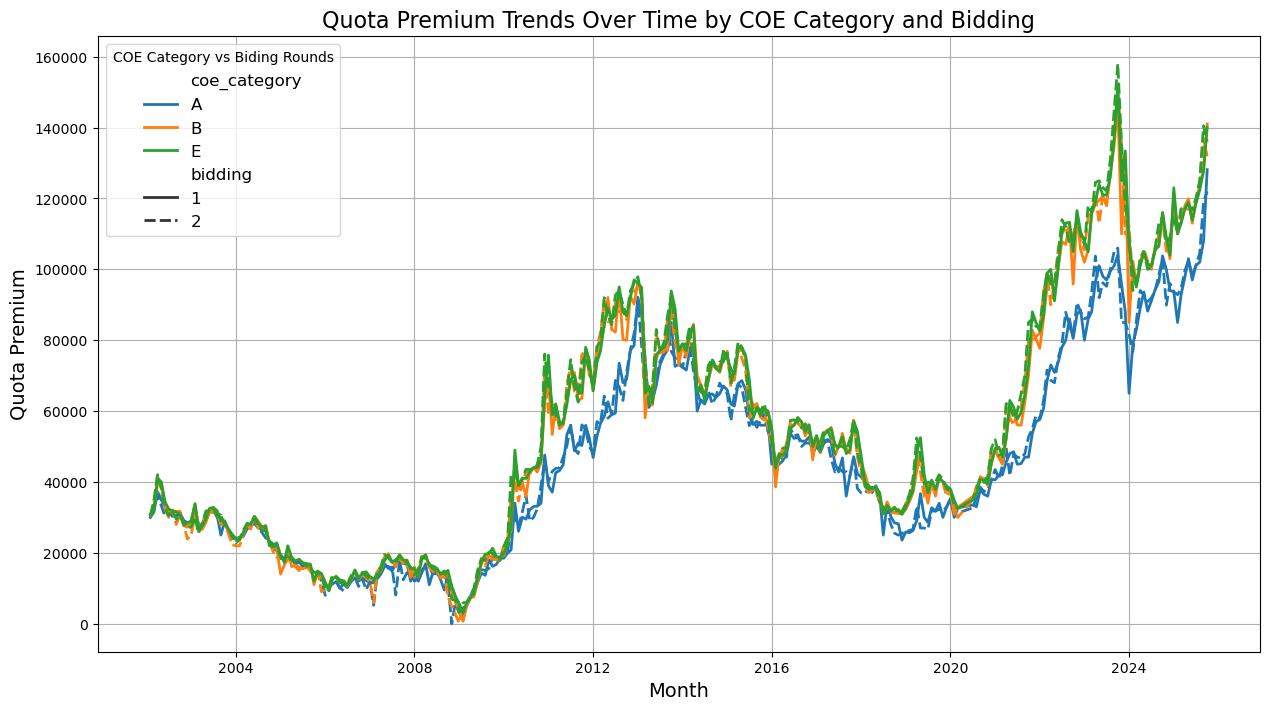

In [12]:
coe_df = coe_df[~coe_df.index.get_level_values('coe_category').isin(['C', 'D'])]

plt.figure(figsize=(15, 8))
sns.lineplot(
    data=coe_df,
    x='month',
    y='quota_premium',
    hue='coe_category',
    style='bidding',
    markers=False,
    dashes=True,
    linewidth=2
)
plt.title("Quota Premium Trends Over Time by COE Category and Bidding", fontsize=16)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Quota Premium", fontsize=14)
plt.legend(title="COE Category vs Biding Rounds", fontsize=12)
plt.grid(True)
plt.show()


In [13]:
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    row_heights=[1, 1, 1],
    subplot_titles=("Quota vs. Quota Premium", "Quota vs. Bids Received", 'Quota Premium vs. Bids Received'),
    specs=[[{"secondary_y": True}], [{}], [{"secondary_y": True}]]
)

#COE Quota
fig.add_trace(go.Scatter(
        x=cat_a_df.index,
        y=cat_a_df['quota_a'],
        mode='lines',
        name='Quota',
        line=dict(color=pc.qualitative.Plotly[0])
), row=1, col=1, secondary_y=False)


#COE Quota Premium
fig.add_trace(go.Scatter(
    x=cat_a_df.index,
    y=cat_a_df['quota_premium_a'],
    mode='lines',
    name='Quota Premium',
    line=dict(color=pc.qualitative.Plotly[1]),
    yaxis='y2'
), row=1, col=1, secondary_y=True)

#Bids Received
fig.add_trace(go.Scatter(
    x=cat_a_df.index,
    y=cat_a_df['bids_received_a'],
    mode='lines',
    name='Bids Received',
    line=dict(color=pc.qualitative.Plotly[2])
), row=2, col=1)

fig.add_trace(go.Scatter(
        x=cat_a_df.index,
        y=cat_a_df['quota_a'],
        mode='lines',
        name='Quota',
        line=dict(color=pc.qualitative.Plotly[0]),
        showlegend=False
), row=2, col=1, secondary_y=False)

fig.add_trace(go.Scatter(
    x=cat_a_df.index,
    y=cat_a_df['quota_premium_a'],
    mode='lines',
    name='Quota Premium',
    line=dict(color=pc.qualitative.Plotly[1]),
    showlegend=False
), row=3, col=1, secondary_y=True)

#Bids Received
fig.add_trace(go.Scatter(
    x=cat_a_df.index,
    y=cat_a_df['bids_received_a'],
    mode='lines',
    name='Bids Received',
    line=dict(color=pc.qualitative.Plotly[2]),
    showlegend=False
), row=3, col=1)

fig.update_layout(
    height=1200,
    width=1000,
    title={
        'text': "Cat A COE Trends",
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 20}
    },
    template='plotly_dark',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.2,
        xanchor="center",
        x=0.5
    )
)

fig.update_xaxes(
    title_text="Month-Year",
)

fig.update_yaxes(title_text="Quota", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="Premium (SGD)", row=1, col=1, secondary_y=True)

fig.update_yaxes(title_text="Quota / Bids", row=2, col=1)

fig.update_yaxes(title_text="Bids", row=3, col=1, secondary_y=False)
fig.update_yaxes(title_text="Premium (SGD)", row=3, col=1, secondary_y=True)

fig.show()

In [14]:
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    row_heights=[1, 1],
    subplot_titles=("Deregistered Vehicles vs. Quota", 'Deregistered Vehicles vs. Quota Premium'),
    specs=[[{"secondary_y": True}], [{"secondary_y": True}]],
)

fig.add_trace(go.Scatter(
        x=cat_a_df.index,
        y=cat_a_df['quota_a'],
        mode='lines',
        name='Quota',
        line=dict(color=pc.qualitative.Plotly[0])
), row=1, col=1, secondary_y=True)


fig.add_trace(go.Scatter(
    x=cat_a_df.index,
    y=cat_a_df['dereg_a'],
    mode='lines',
    name='Dereg Vehicle',
    line=dict(color=pc.qualitative.Plotly[4]),
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=cat_a_df.index,
    y=cat_a_df['quota_premium_a'],
    mode='lines',
    name='Quota Premium',
    line=dict(color=pc.qualitative.Plotly[1]),
), row=2, col=1, secondary_y=True)

fig.add_trace(go.Scatter(
    x=cat_a_df.index,
    y=cat_a_df['dereg_a'],
    mode='lines',
    name='Dereg Vehicle',
    line=dict(color=pc.qualitative.Plotly[4]),
    showlegend=False
), row=2, col=1, secondary_y=False)

fig.update_layout(
    height=900,
    width=1000,
    title={
        'text': "Cat A COE Trends",
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 20}
    },
    template='plotly_dark',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.2,
        xanchor="center",
        x=0.5
    )
)

fig.update_yaxes(title_text="Quota", row=1, col=1, secondary_y=True)
fig.update_yaxes(title_text="Vehicles", row=1, col=1, secondary_y=False)
fig.update_xaxes(title_text="Month", row=1, col=1)

fig.update_yaxes(title_text="Premium (SGD)", row=2, col=1, secondary_y=True)
fig.update_yaxes(title_text="Vehicles", row=2, col=1, secondary_y=False)
fig.update_xaxes(title_text="Month", row=2, col=1)

fig.show()

In [15]:
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    row_heights=[1, 1],
    subplot_titles=("Quota vs. COE Yearly", "Quota Premium vs. COE Yearly"),
    specs=[[{"secondary_y": True}], [{"secondary_y": True}]]
)

#Plot 1: Quota vs COE Yearly
fig.add_trace(go.Scatter(
        x=cat_a_df.index,
        y=cat_a_df['quota_a'],
        mode='lines',
        name='Quota',
        line=dict(color=pc.qualitative.Plotly[0])
), row=1, col=1, secondary_y=False)

fig.add_trace(go.Scatter(
    x=coe_yearly_a.index,
    y=coe_yearly_a['5 Year'],
    mode='lines',
    name='5 Year COE Revalidation',
    line=dict(color=pc.qualitative.Plotly[5]),
), row=1, col=1, secondary_y=True)

fig.add_trace(go.Scatter(
    x=coe_yearly_a.index,
    y=coe_yearly_a['10 Year'],
    mode='lines',
    name='10 Year COE Revalidation',
    line=dict(color=pc.qualitative.Plotly[6]),
), row=1, col=1, secondary_y=True)

#Plot 2: Quota Premium vs COE Yearly

fig.add_trace(go.Scatter(
    x=cat_a_df.index,
    y=cat_a_df['quota_premium_a'],
    mode='lines',
    name='Quota Premium',
    line=dict(color=pc.qualitative.Plotly[1])
), row=2, col=1, secondary_y=False)

fig.add_trace(go.Scatter(
    x=coe_yearly_a.index,
    y=coe_yearly_a['5 Year'],
    mode='lines',
    name='5 Year COE Revalidation',
    line=dict(color=pc.qualitative.Plotly[5]),
), row=2, col=1, secondary_y=True)

fig.add_trace(go.Scatter(
    x=coe_yearly_a.index,
    y=coe_yearly_a['10 Year'],
    mode='lines',
    name='10 Year COE Revalidation',
    line=dict(color=pc.qualitative.Plotly[6]),
), row=2, col=1, secondary_y=True)

fig.update_layout(
    height=900,
    width=1000,
    title={
        'text': "Cat A COE Trends",
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 20}
    },
    template='plotly_dark',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.2,
        xanchor="center",
        x=0.5
    )
)

fig.update_xaxes(
    title_text="Year",
)

fig.update_yaxes(title_text="Quota", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="COE Revaluation (5Y & 10Y)", row=1, col=1, secondary_y=True)

fig.update_yaxes(title_text="Quota Premium (SGD)", row=2, col=1, secondary_y=False)
fig.update_yaxes(title_text="COE Revaluation (5Y & 10Y)", row=2, col=1, secondary_y=True)

fig.show()

Spearman Correlation Matrix:
                  quota_a  bids_received_a  quota_premium_a   dereg_a
quota_a          1.000000         0.947654        -0.706359  0.855338
bids_received_a  0.947654         1.000000        -0.632153  0.854075
quota_premium_a -0.706359        -0.632153         1.000000 -0.534087
dereg_a          0.855338         0.854075        -0.534087  1.000000

P-Value Matrix:
                       quota_a  bids_received_a  quota_premium_a       dereg_a
quota_a           0.000000e+00    2.438058e-142     2.286258e-44  8.221611e-83
bids_received_a  2.438058e-142     0.000000e+00     3.312895e-33  2.558927e-82
quota_premium_a   2.286258e-44     3.312895e-33     0.000000e+00  2.028590e-22
dereg_a           8.221611e-83     2.558927e-82     2.028590e-22  0.000000e+00


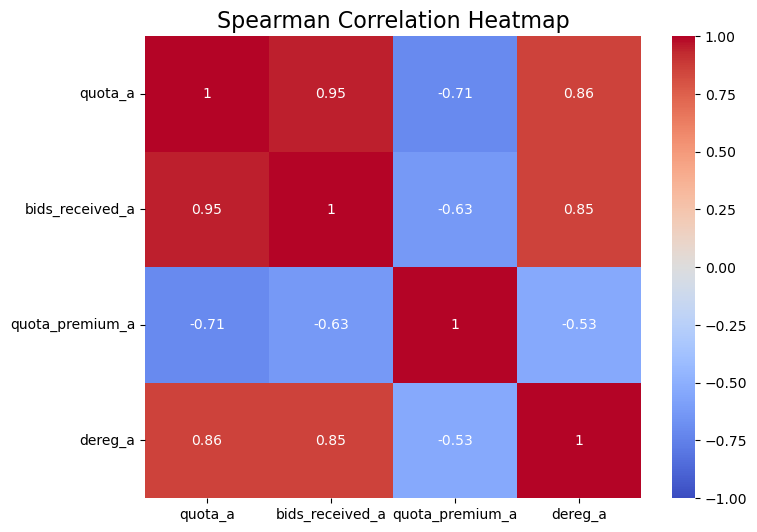

In [16]:
new_cat_a = cat_a_df[['quota_a', 'bids_received_a', 'quota_premium_a', 'dereg_a']].copy()

#dereg value for Dec 24 taken from LTA website
new_cat_a.loc['2024-12-01', 'dereg_a'] = 1973

#interpolate missing values btw Apr 20 to Jun 20
new_cat_a.interpolate(method='time', inplace=True)
new_cat_a = new_cat_a.round(1)

def spearman_pval(df):
    cols = df.columns
    corr_matrix = np.zeros((len(cols), len(cols)))
    pval_matrix = np.zeros((len(cols), len(cols)))

    for i, col1 in enumerate(cols):
        for j, col2 in enumerate(cols):
            corr, pval = spearmanr(df[col1], df[col2])
            corr_matrix[i, j] = corr
            pval_matrix[i, j] = pval

    corr_df = pd.DataFrame(corr_matrix, columns=cols, index=cols)
    pval_df = pd.DataFrame(pval_matrix, columns=cols, index=cols)

    return corr_df, pval_df

corr_df, pval_df = spearman_pval(new_cat_a)

print("Spearman Correlation Matrix:")
print(corr_df)

print("\nP-Value Matrix:")
print(pval_df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_df,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)
plt.title("Spearman Correlation Heatmap", fontsize=16)
plt.show()

Findings (Spearman)

| Pair            | Spearman ρ | Meaning                          |
| --------------- | ---------- | -------------------------------- |
| quota ↔ bids    | **+0.95**  | Very strong monotonic positive   |
| quota ↔ dereg   | **+0.85**  | Strong structural linkage        |
| quota ↔ premium | **−0.74**  | Strong inverse monotonic         |
| bids ↔ premium  | **−0.67**  | Demand drops as prices rise      |
| dereg ↔ premium | **−0.55**  | Supply pipeline suppresses price |

All relationships are statistically significant (p ≈ 0).

1. COE prices are supply-constrained
- Quota changes dominate price direction
- Demand adjusts to price

2. Deregistration acts as a leading indicator
- Dereg ↔ quota strong
- Dereg ↔ premium weaker

Hypothesis 1 - Supply Dominance
- COE premiums are primarily driven by quota availability, with demand responding elastically to price rather than determining price.

Hypothesis 2 — Vehicle Dereg as leading indicator
- Vehicle deregistration influences COE premiums indirectly through quota adjustments, introducing a lagged supply effect rather than immediate price response.

However:
- High correlations between trending series can be spurious
- Time-series variables must be checked for stationarity before inference or modeling


In [17]:
#Stationarity test for raw features

def adf_test(series, series_name):
    adf_summaries = []
    for columns in series.columns:
        adf_results = adfuller(series[columns])
        adf_summary = {
            'ADF Statistic': adf_results[0],
            'p-value': adf_results[1],
            '1%': adf_results[4]['1%'],
            '5%': adf_results[4]['5%'],
            '10%': adf_results[4]['10%'],
        }
        adf_summaries.append(adf_summary)
    adf_df = pd.DataFrame(adf_summaries, index=series.columns)
    print(f"ADF Test Results for {series_name}")
    print(adf_df)

log_cat_a = np.log(new_cat_a.replace(0, np.nan))
diff_cat_a = new_cat_a.diff().dropna()
diff_log_cat_a = log_cat_a.diff().dropna()

adf_test(new_cat_a, "Cat A Original")
adf_test(log_cat_a, "Cat A Log-Transformed")
adf_test(diff_cat_a, "Cat A Differenced")
adf_test(diff_log_cat_a, "Cat A Log-Differenced")


ADF Test Results for Cat A Original
                 ADF Statistic   p-value        1%        5%       10%
quota_a              -2.669389  0.079487 -3.454622 -2.872225 -2.572464
bids_received_a      -1.734579  0.413390 -3.454713 -2.872265 -2.572485
quota_premium_a       0.748850  0.990764 -3.453838 -2.871881 -2.572280
dereg_a              -2.013699  0.280599 -3.454622 -2.872225 -2.572464
ADF Test Results for Cat A Log-Transformed
                 ADF Statistic   p-value        1%        5%       10%
quota_a              -2.599669  0.093066 -3.454622 -2.872225 -2.572464
bids_received_a      -2.472800  0.122233 -3.454896 -2.872345 -2.572528
quota_premium_a      -1.110068  0.711040 -3.454804 -2.872305 -2.572506
dereg_a              -2.038635  0.269894 -3.454622 -2.872225 -2.572464
ADF Test Results for Cat A Differenced
                 ADF Statistic       p-value        1%        5%       10%
quota_a              -2.623031  8.833007e-02 -3.454622 -2.872225 -2.572464
bids_received_a      -

ADF Results — Original & Log-Transformed Series
- ADF p-values > 0.05

Inference:
- All series are non-stationary in levels, even after log transformation.
- Strong structural trends
- Policy-driven regime shifts

ADF Results — Differenced & Log-Differenced Series
- Most variables become stationary
- After log-differencing, all variables reject the unit root hypothesis

Inference:
- The variables are integrated of order 1 (I(1)).
- Levels drift over time, but changes are stable and statistically well-behaved.

1. Structural Insight
- COE prices are trend-dominated, not mean-reverting
- Supply (quota) acts as the primary anchor
- Demand responds to price rather than setting it

2. Statistical Insight
- Correlations in levels reflect long-run co-movement
- Predictive modeling must be done on differences, growth rates or detrended residuakls

3. Policy Insight
- Deregistration affects prices indirectly, through quota mechanisms and with lag

Hypothesis 1 — Supply Dominance
- COE premiums are primarily driven by quota availability, with demand adjusting elastically to price rather than determining price levels.

Hypothesis 2 — Policy Pipeline Effect
- Vehicle deregistration influences COE premiums indirectly through quota adjustments, introducing lagged supply effects rather than immediate price response.

Hypothesis 3 — Structural Non-Stationarity
- COE price dynamics are governed by policy-induced structural shifts rather than stable cyclical behaviour.

Hypothesis 4 — Limited Forecastability
- After accounting for trend and quota effects, residual price movements exhibit limited and unstable predictability.

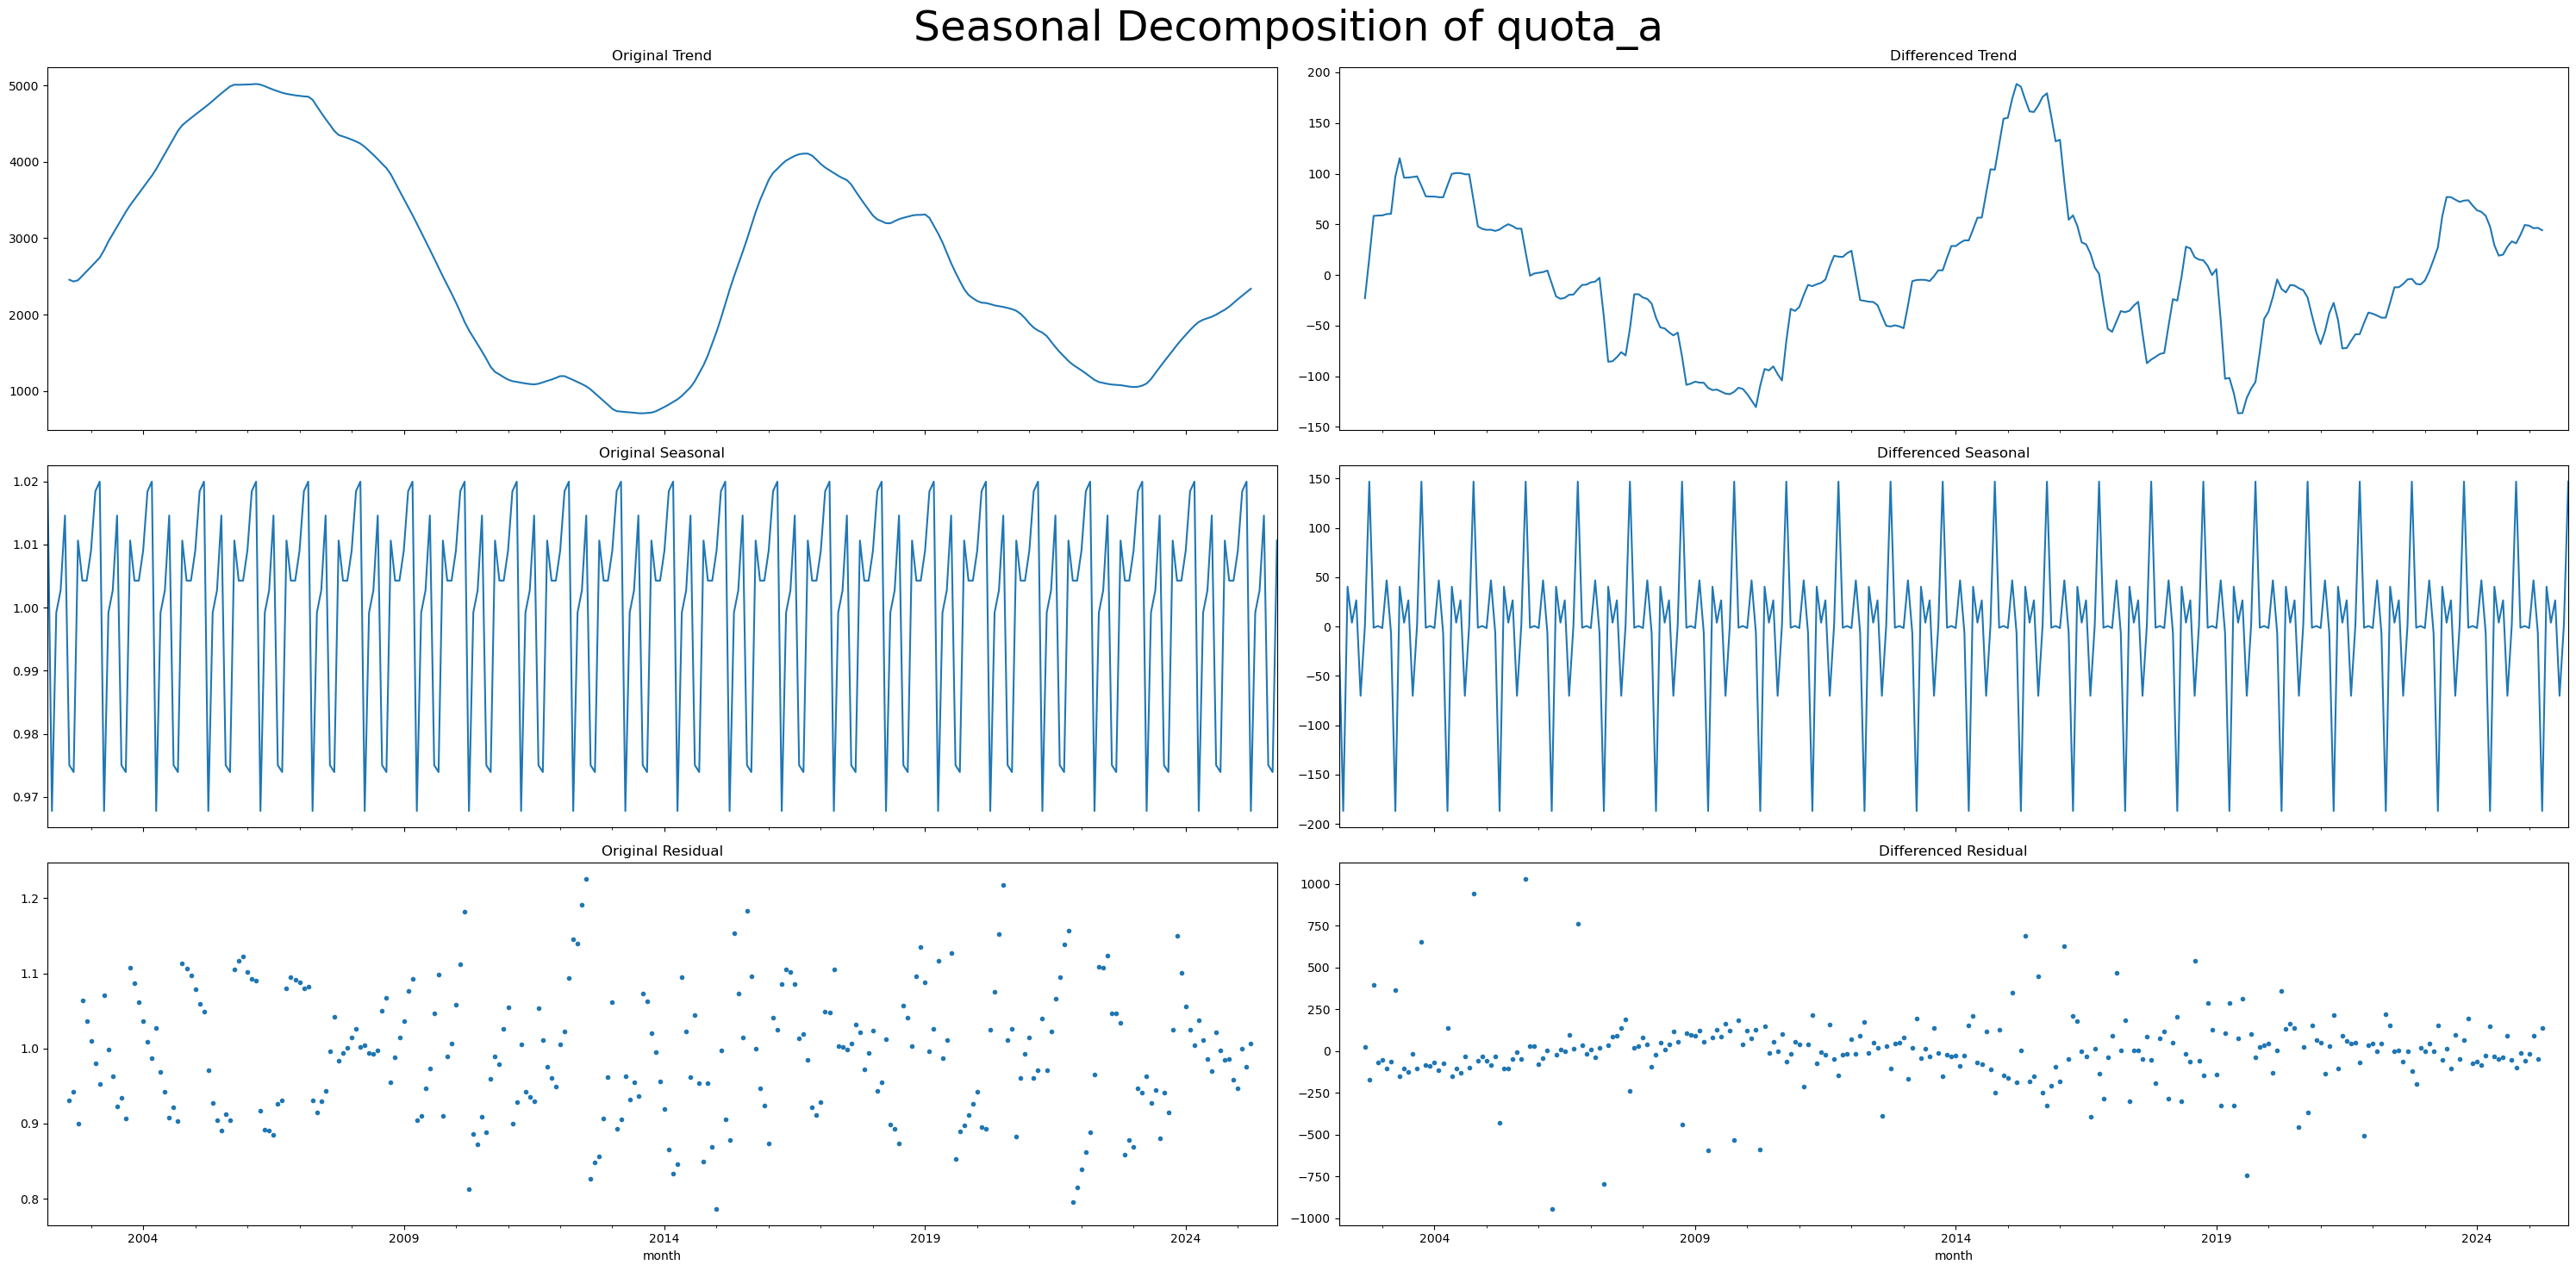

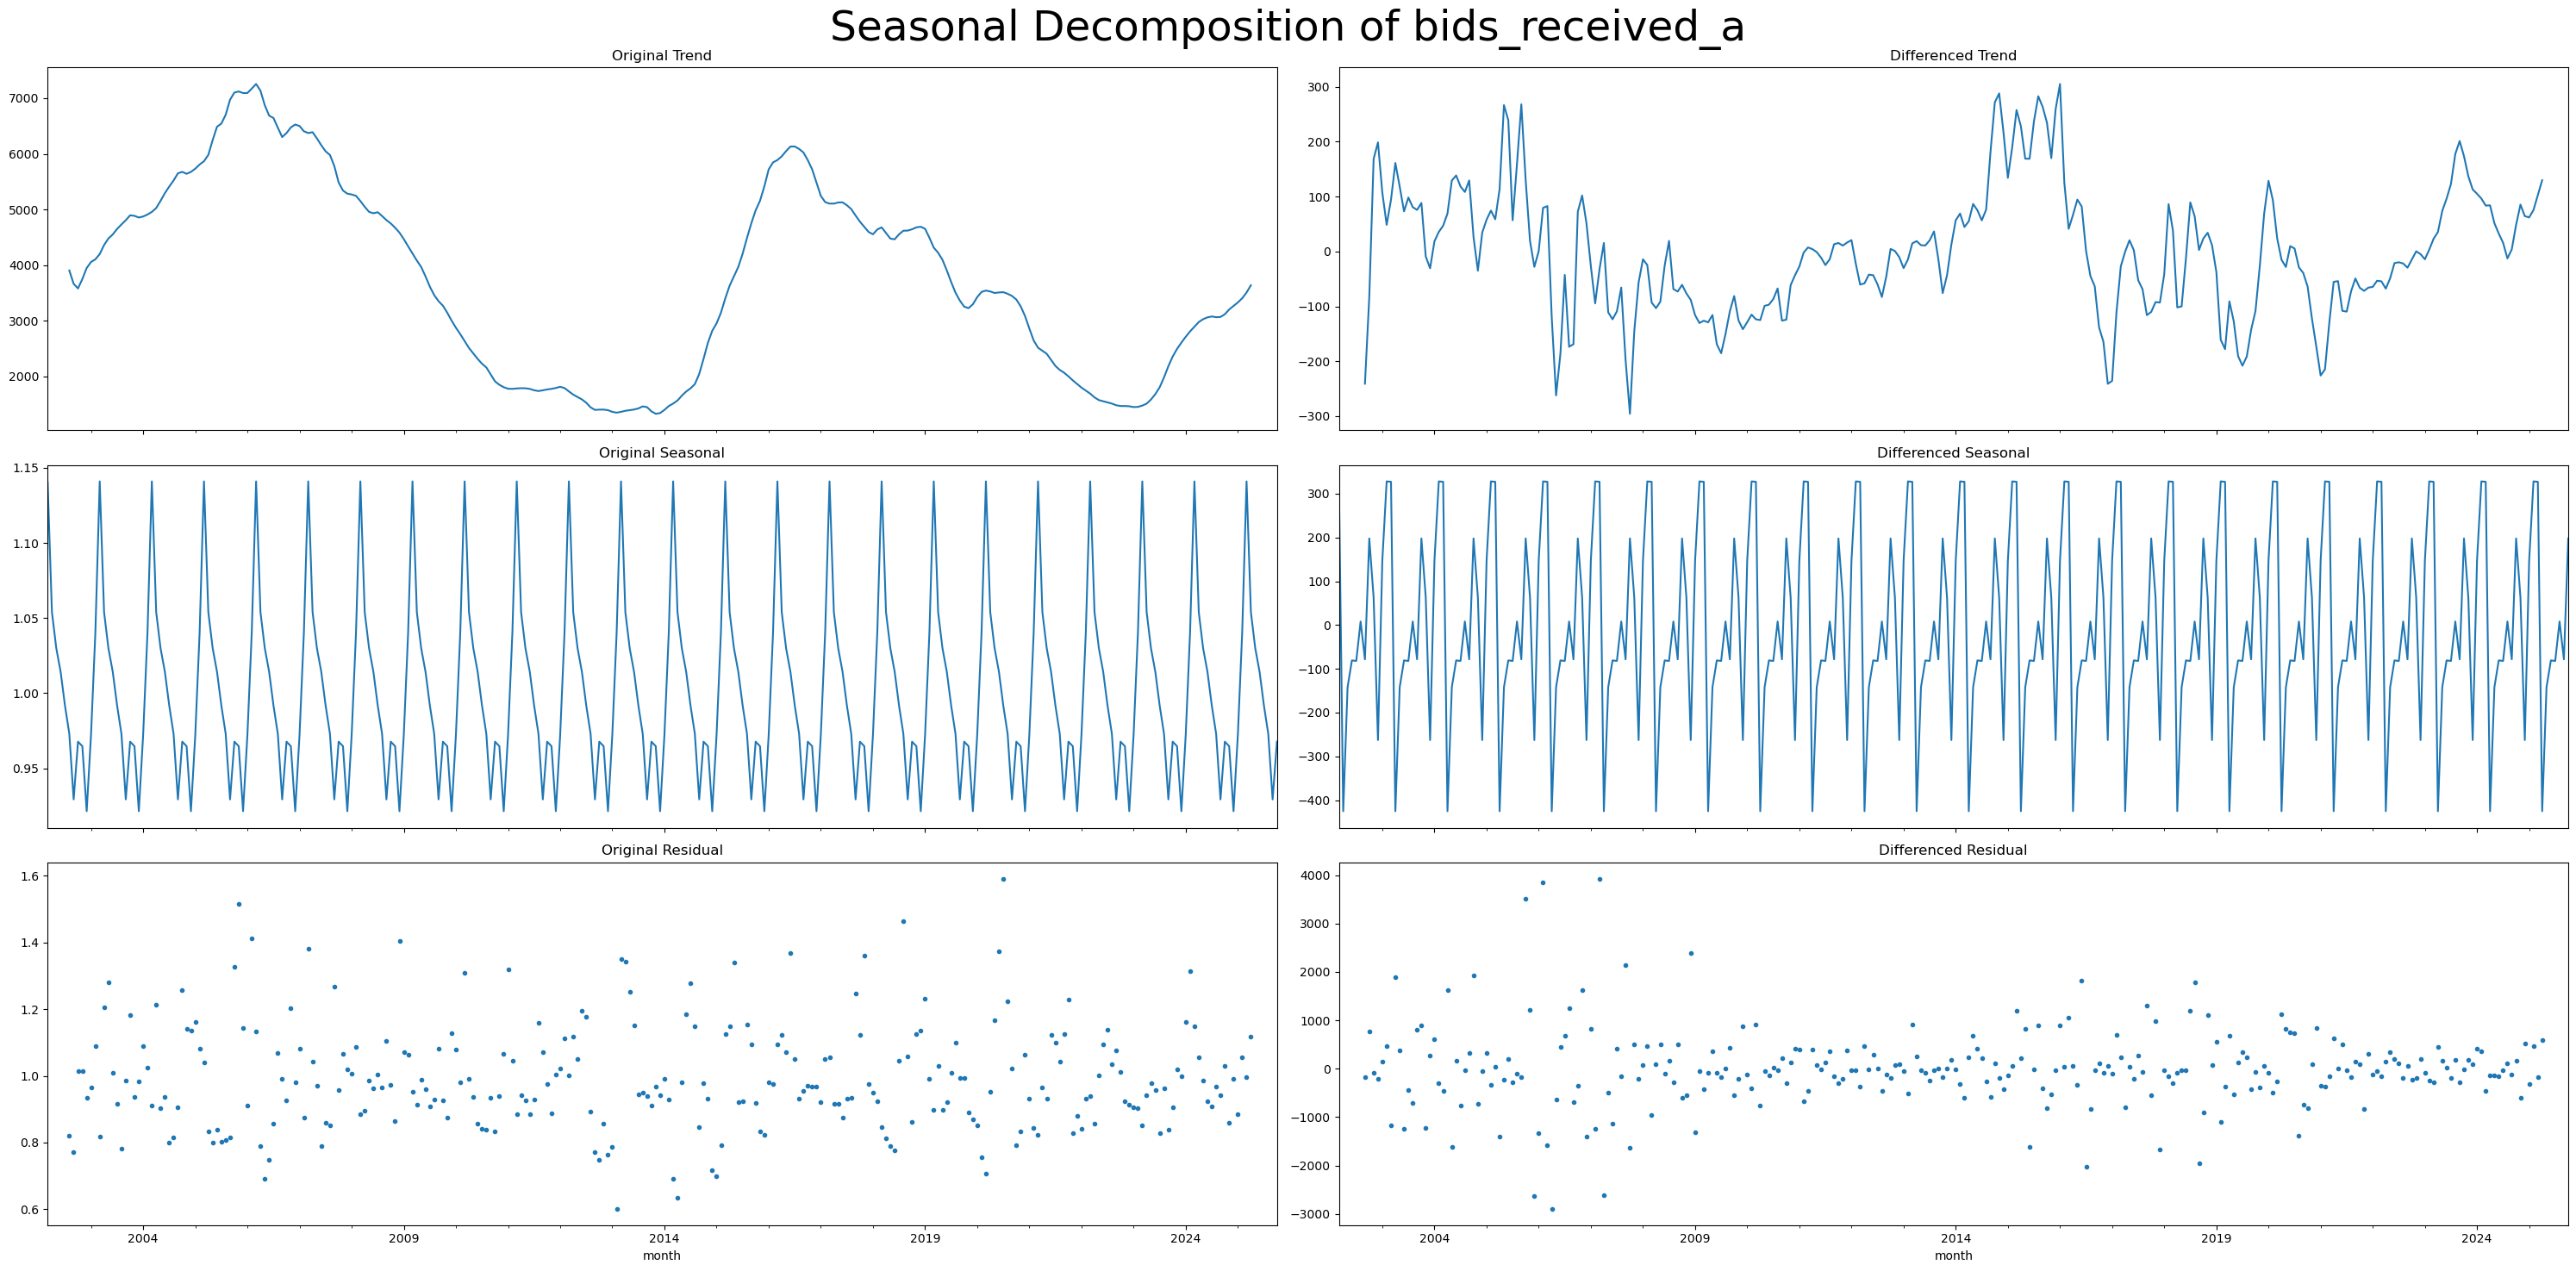

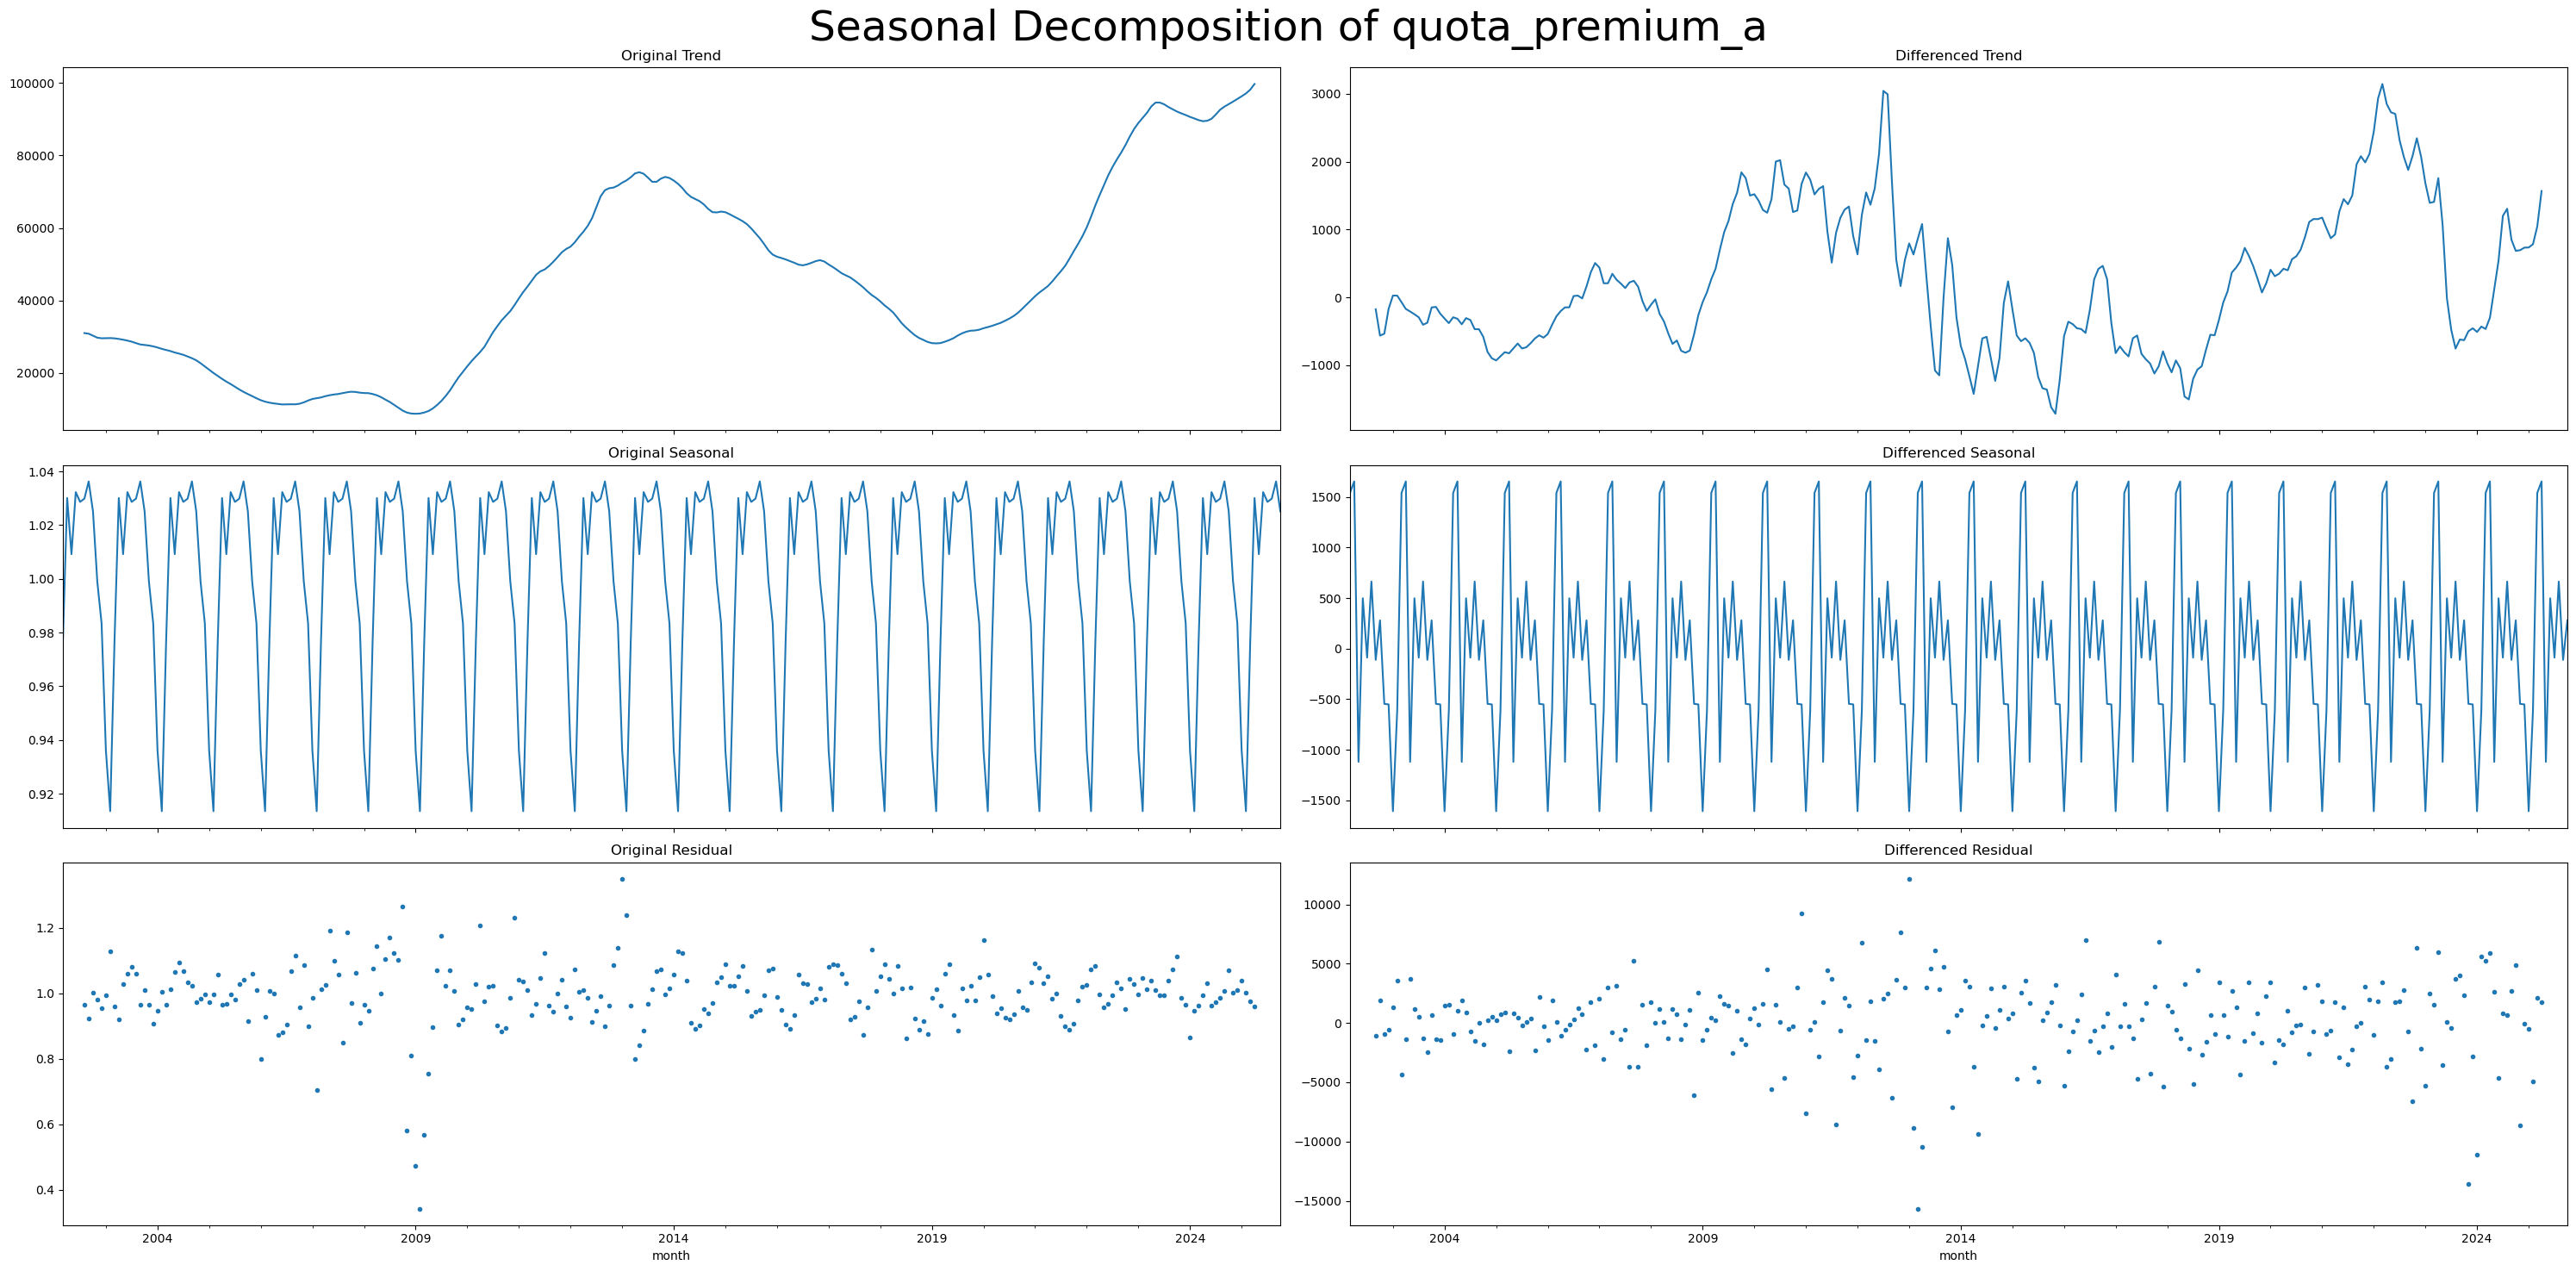

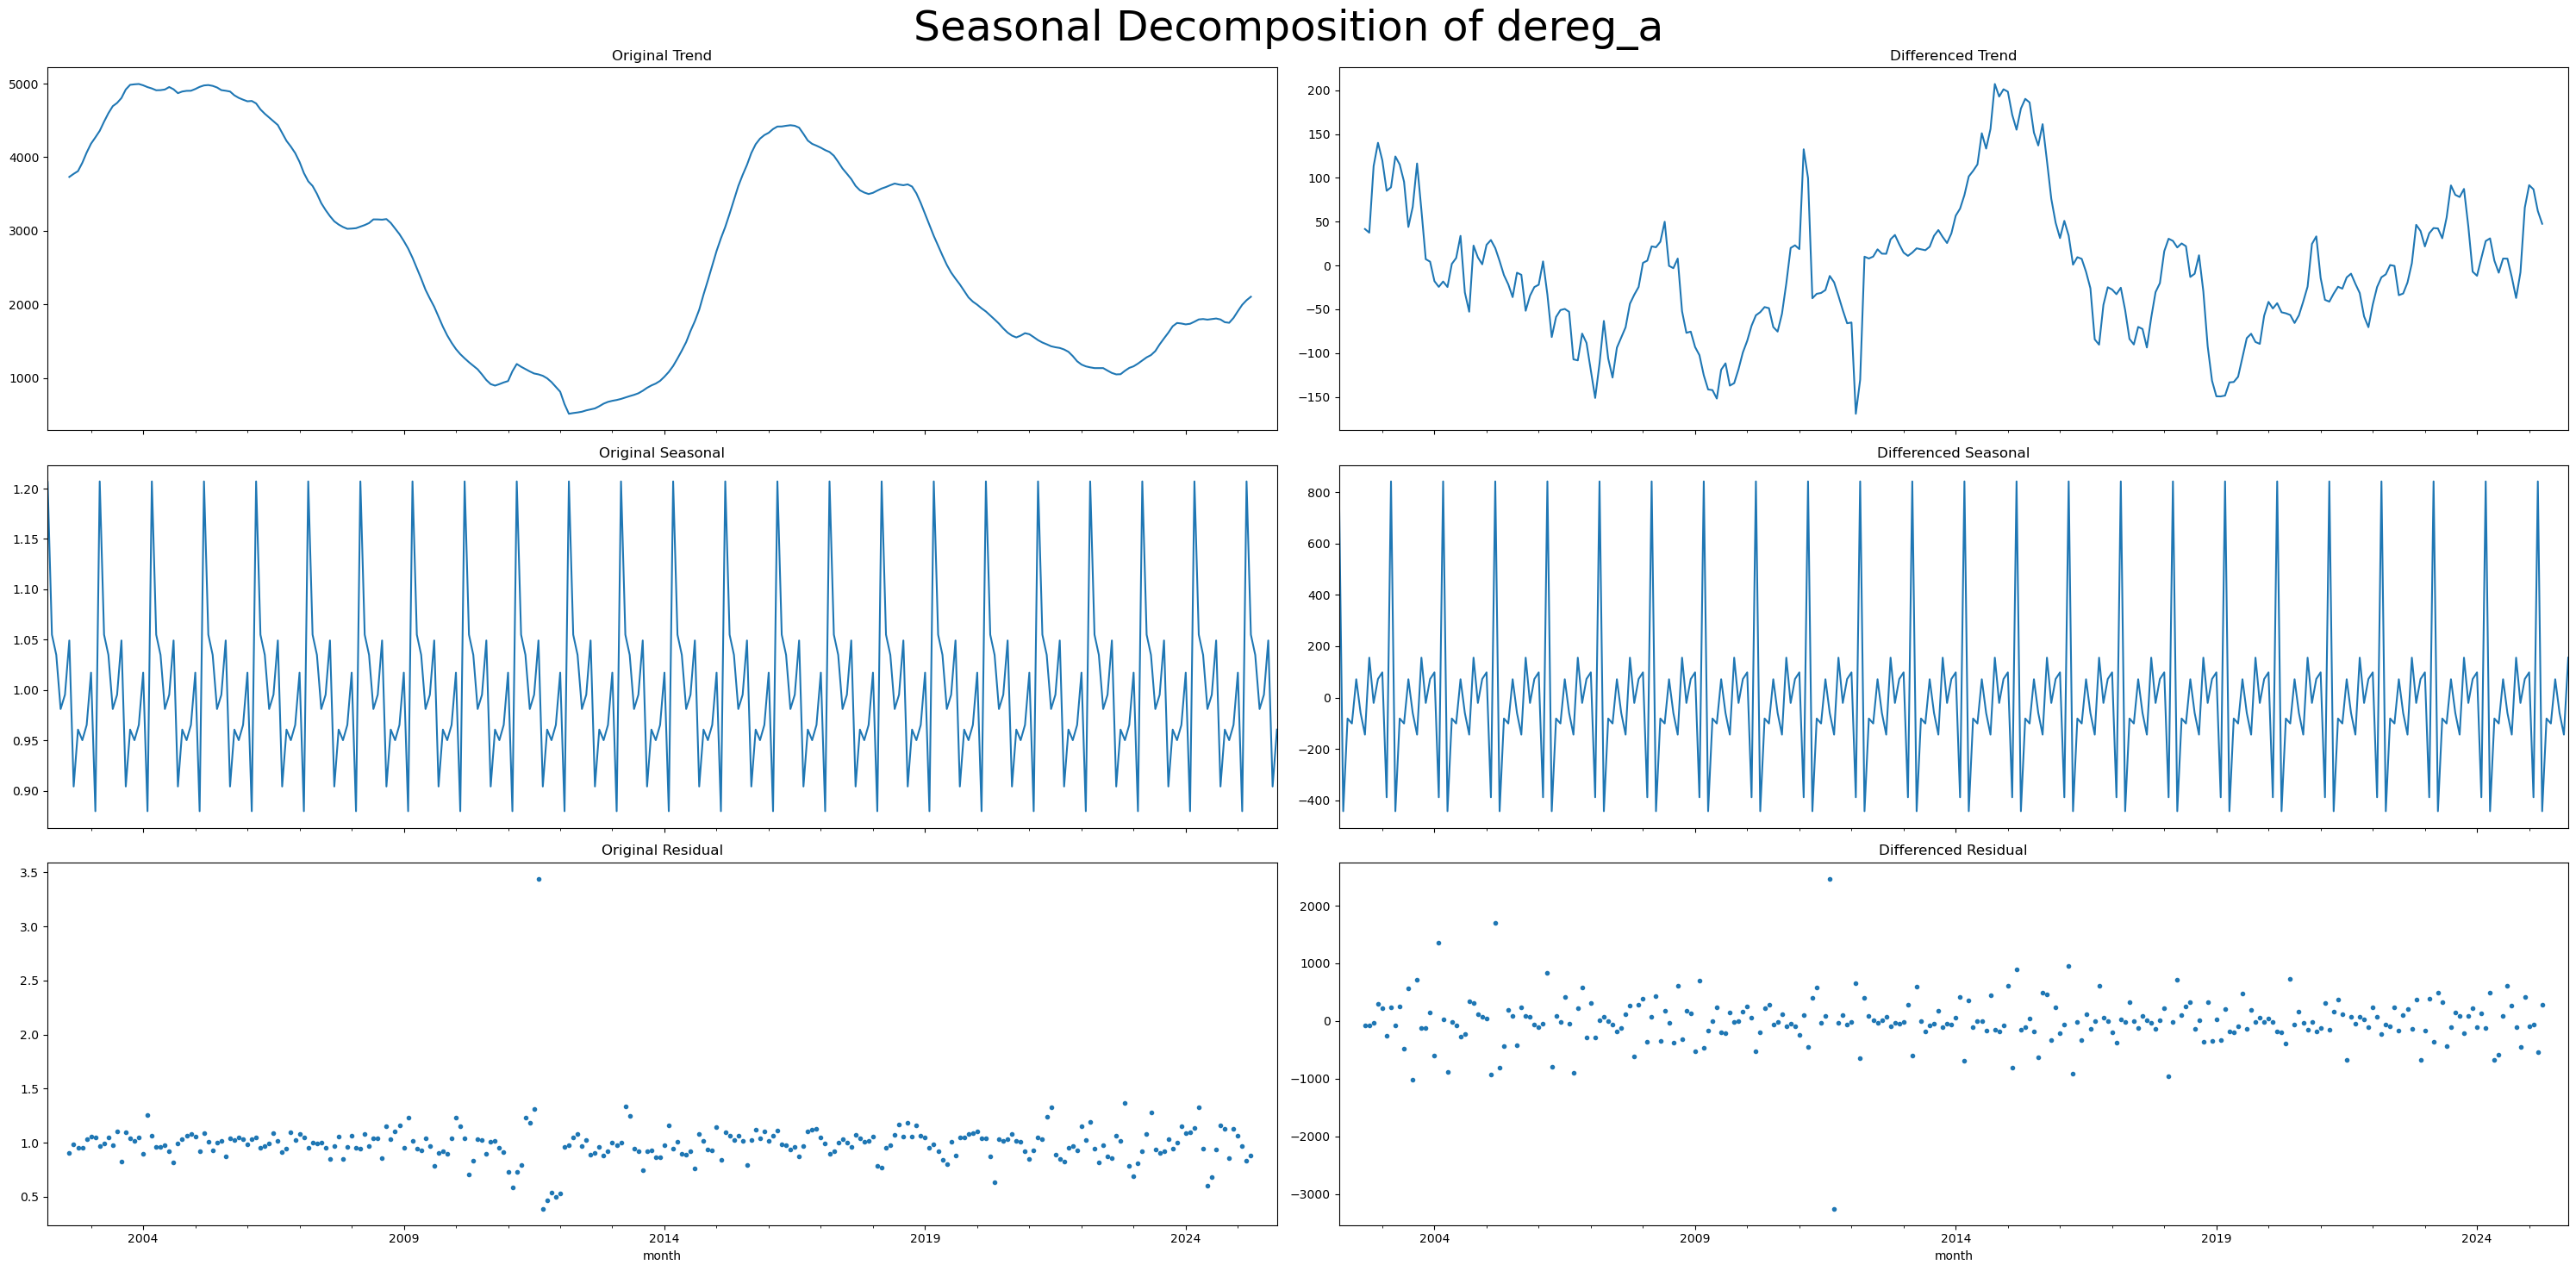

In [18]:
period = 12
components = {'original': {}, 'differenced': {}, 'log': {}, 'log_diff': {}}  

for col in new_cat_a.columns:
    decomposition_original = seasonal_decompose(new_cat_a[col], model='multiplicative', period=period)
    decomposition_diff = seasonal_decompose(diff_cat_a[col], model='additive', period=period)

    components['original'][col] = {
        'trend': decomposition_original.trend,
        'seasonal': decomposition_original.seasonal,
        'residual': decomposition_original.resid
    }

    components['differenced'][col] = {
        'trend': decomposition_diff.trend,
        'seasonal': decomposition_diff.seasonal,
        'residual': decomposition_diff.resid
    }

    fig, axes = plt.subplots(3, 2, figsize=(30, 15), sharex=True)
    fig.suptitle(f"Seasonal Decomposition of {col}", fontsize=35)

    decomposition_original.trend.plot(ax=axes[0, 0], title="Original Trend")
    decomposition_original.seasonal.plot(ax=axes[1, 0], title="Original Seasonal")
    decomposition_original.resid.plot(ax=axes[2, 0], title="Original Residual", style='.')

    decomposition_diff.trend.plot(ax=axes[0, 1], title="Differenced Trend")
    decomposition_diff.seasonal.plot(ax=axes[1, 1], title="Differenced Seasonal")
    decomposition_diff.resid.plot(ax=axes[2, 1], title="Differenced Residual", style='.')

    plt.tight_layout()
    plt.show()




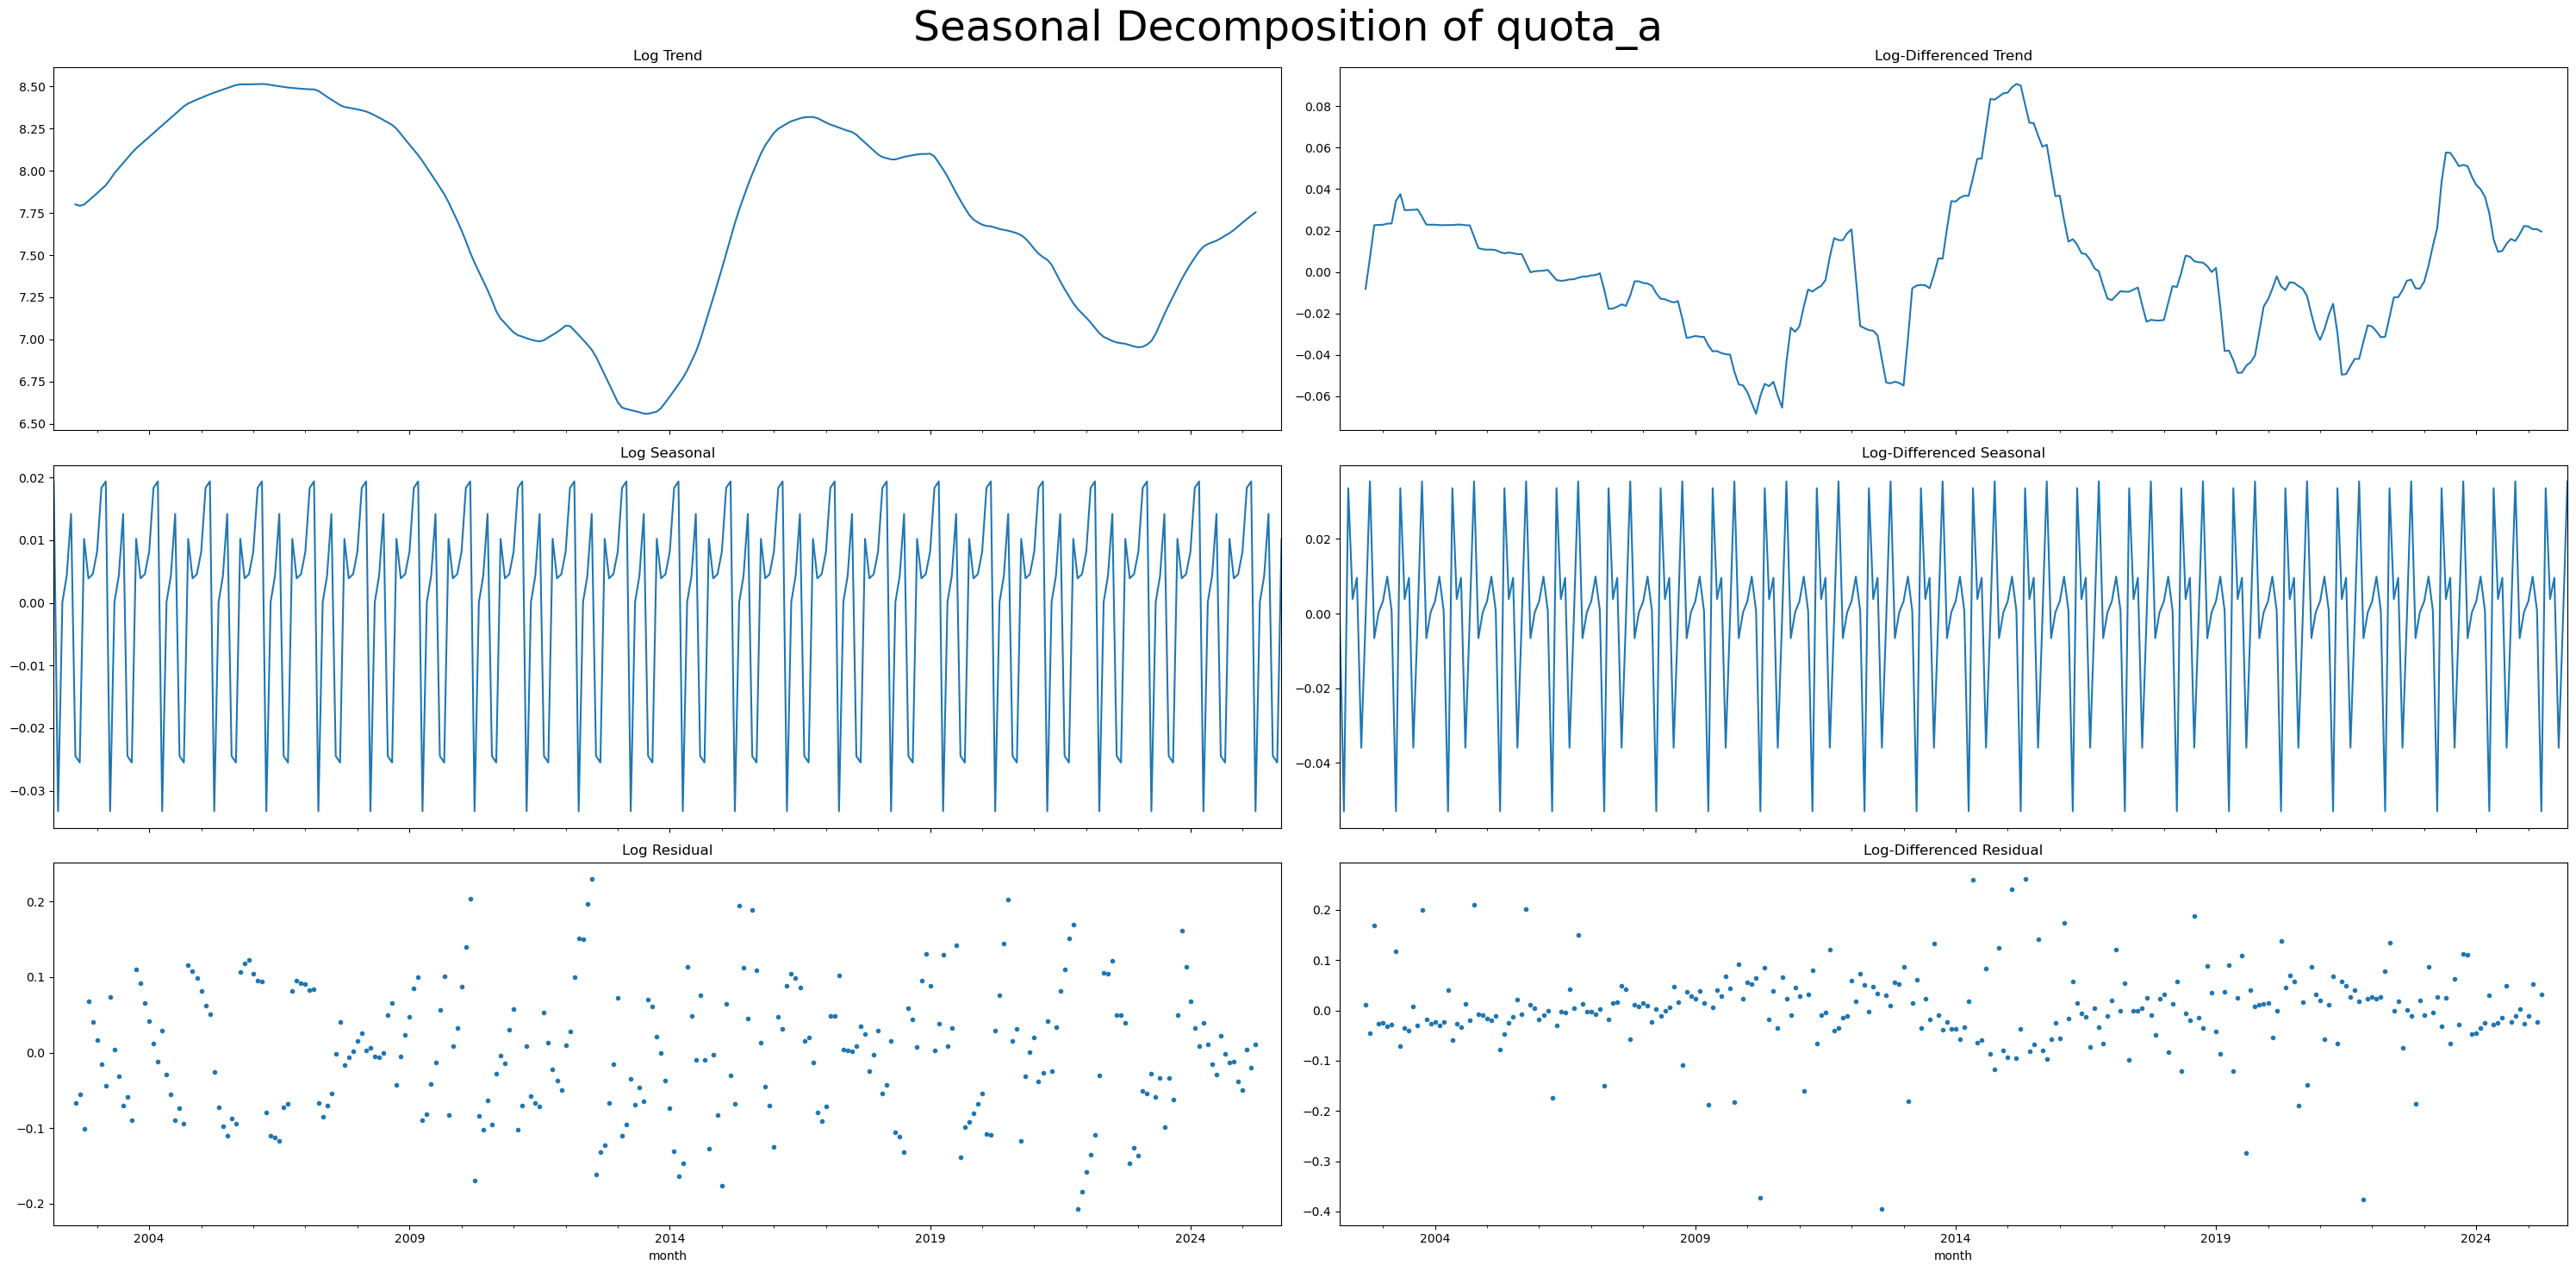

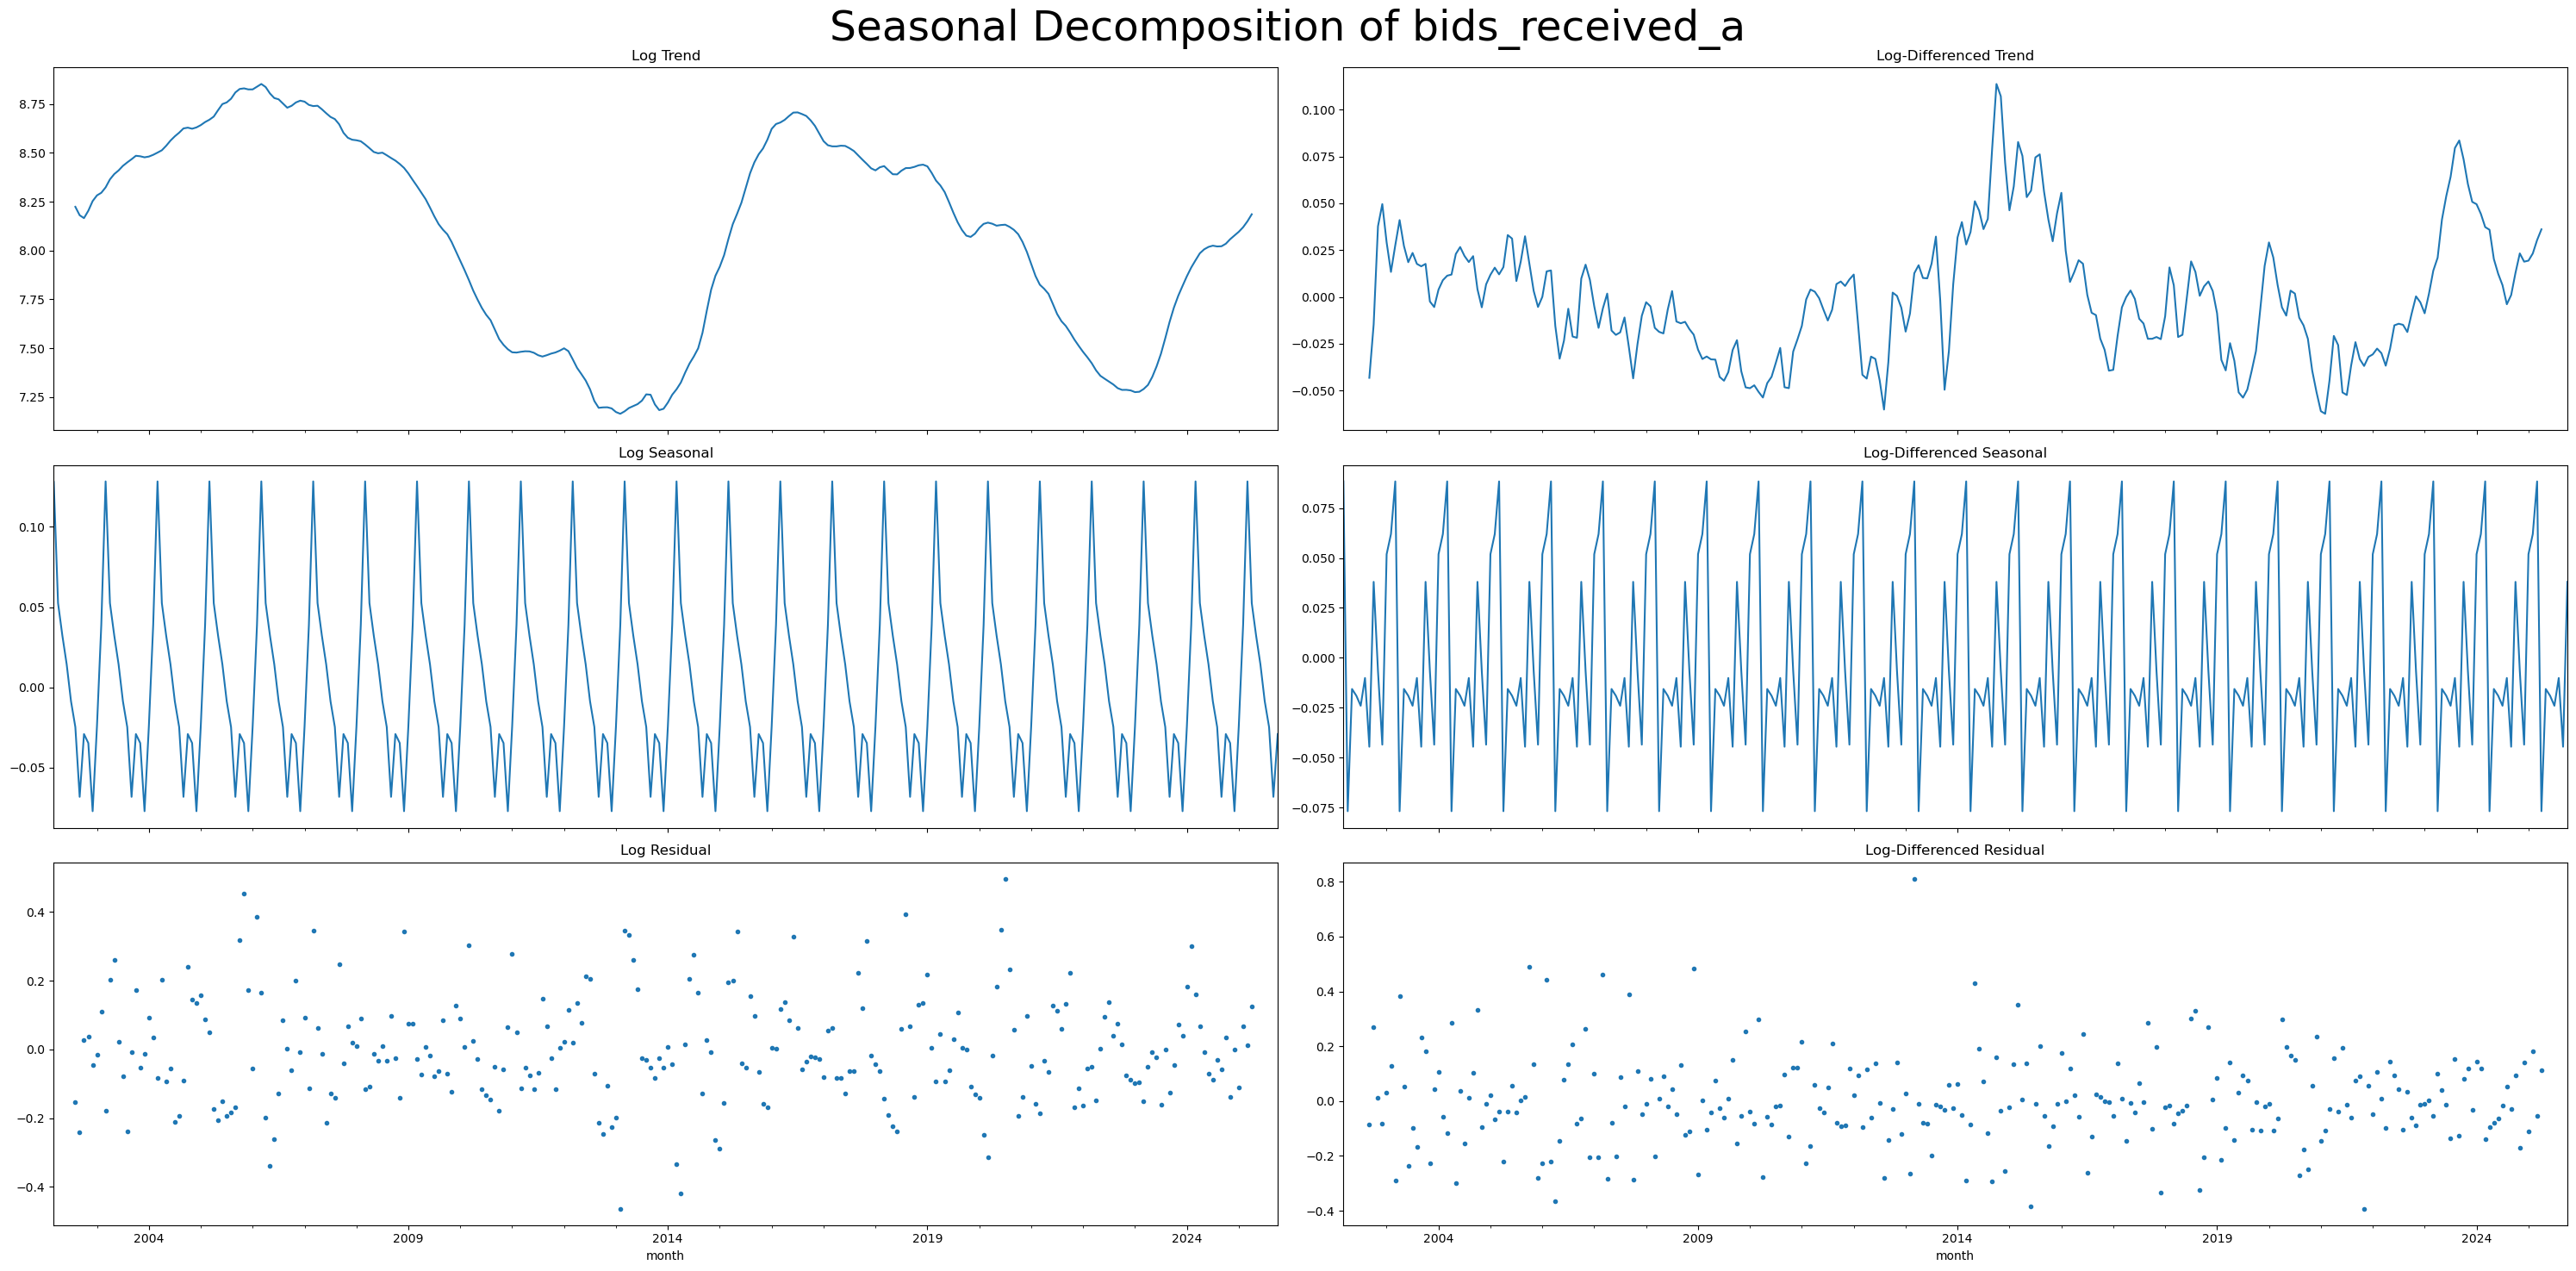

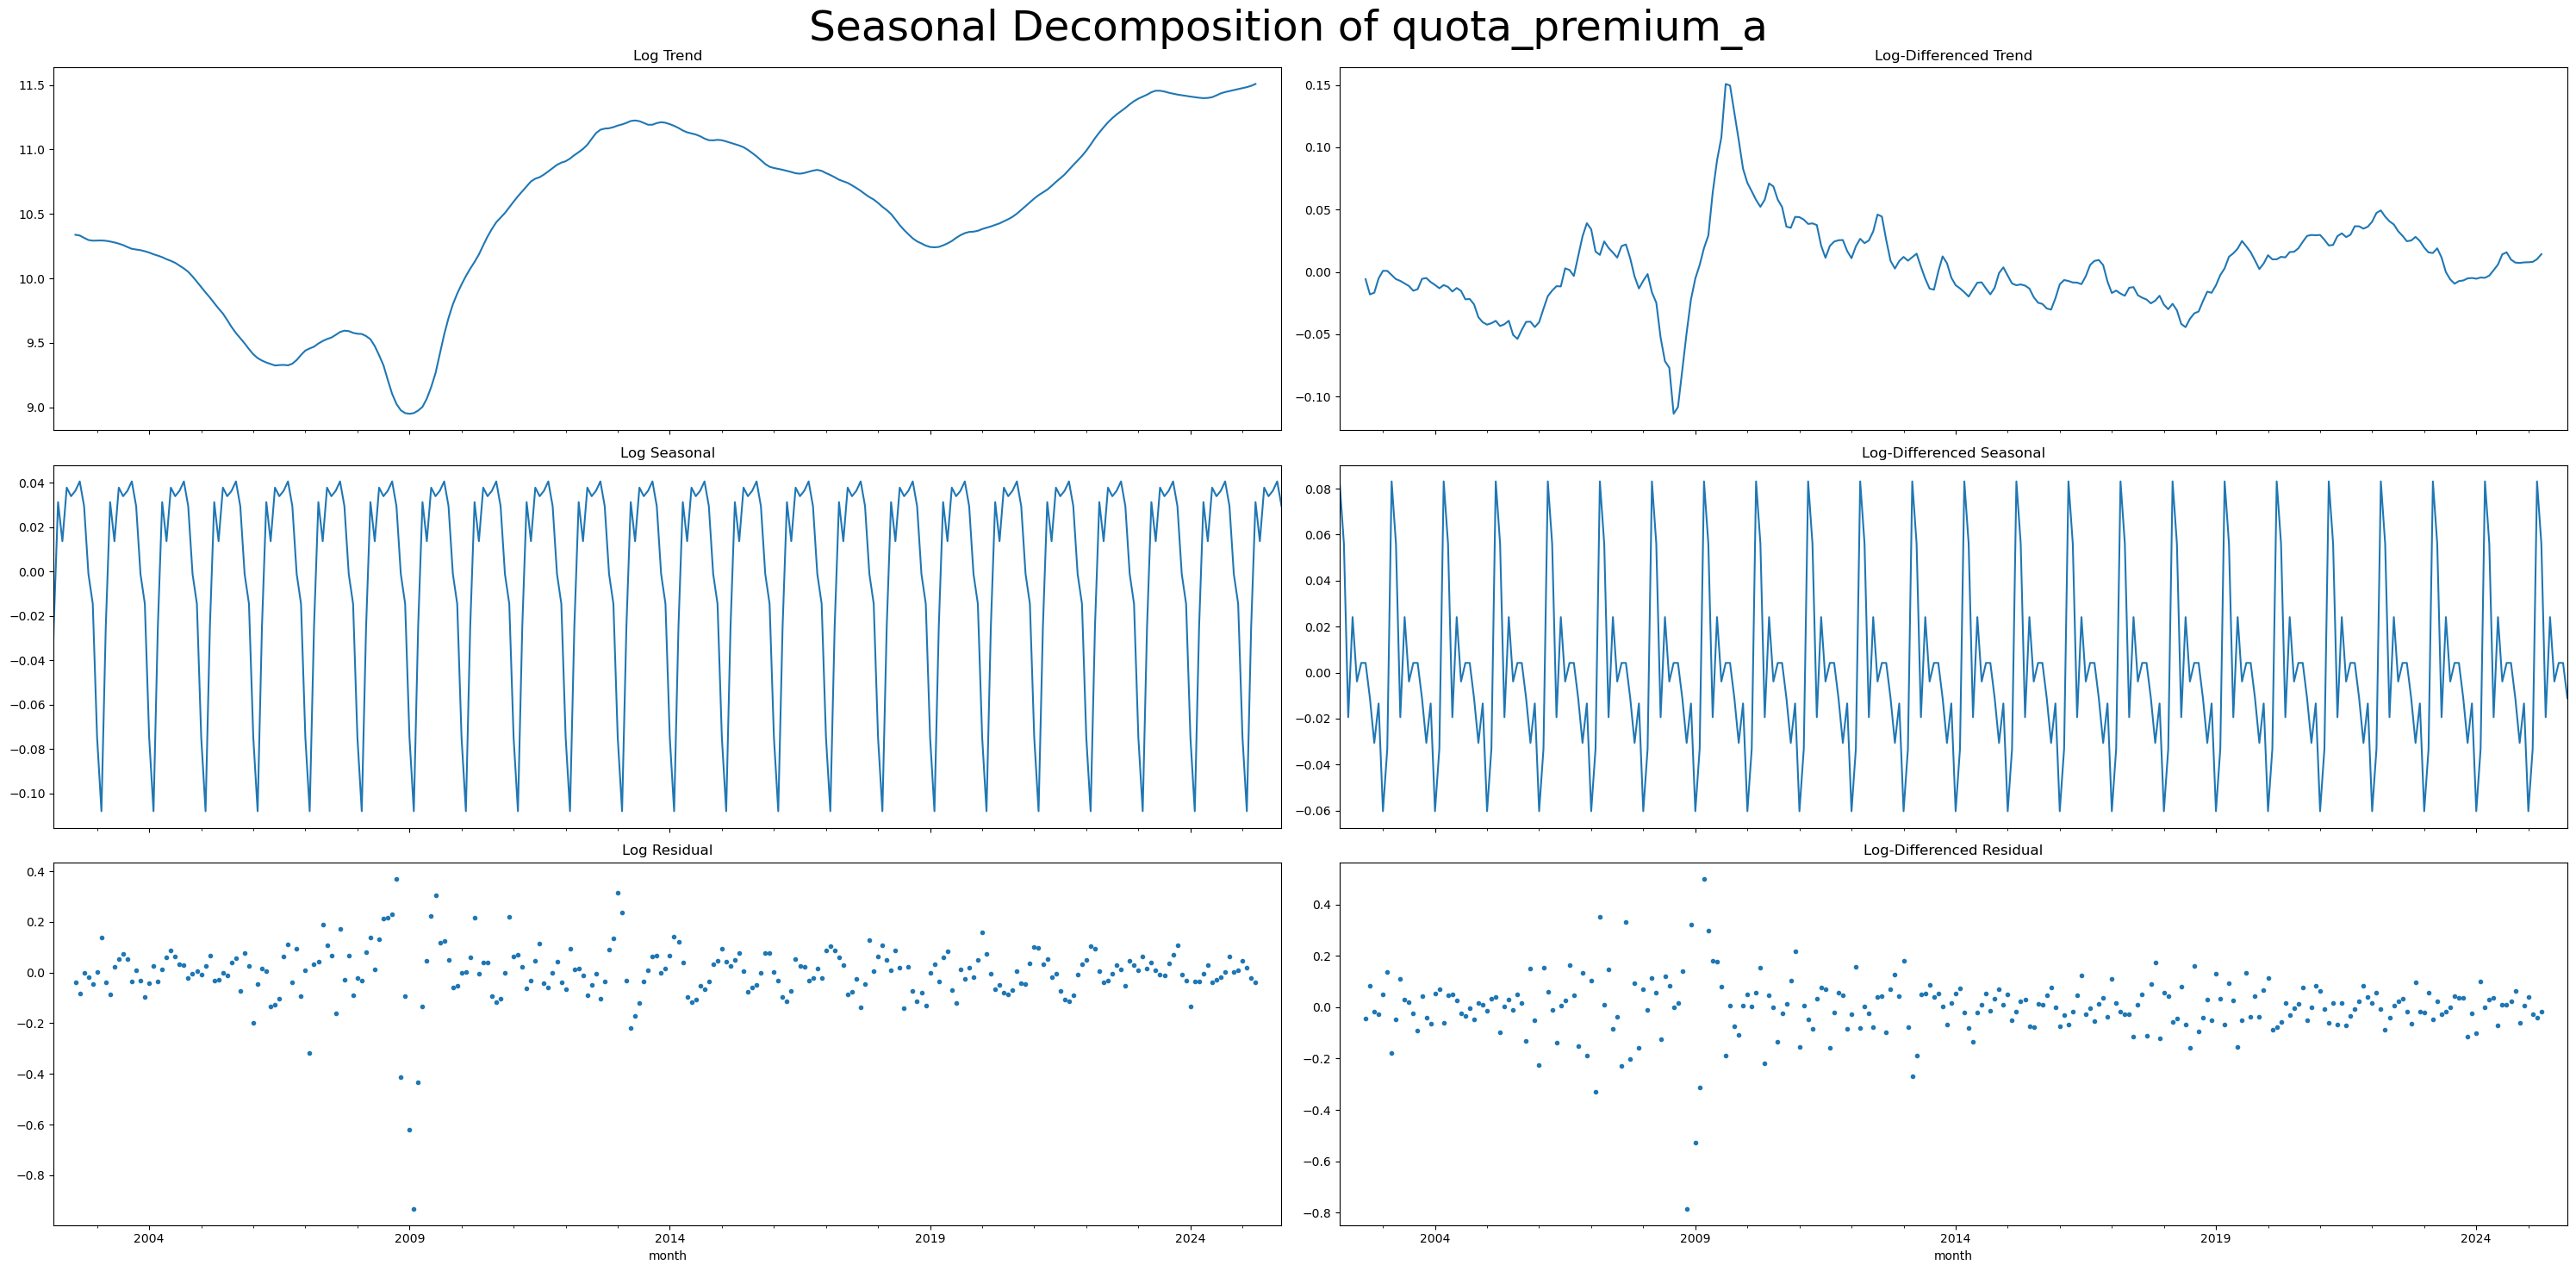

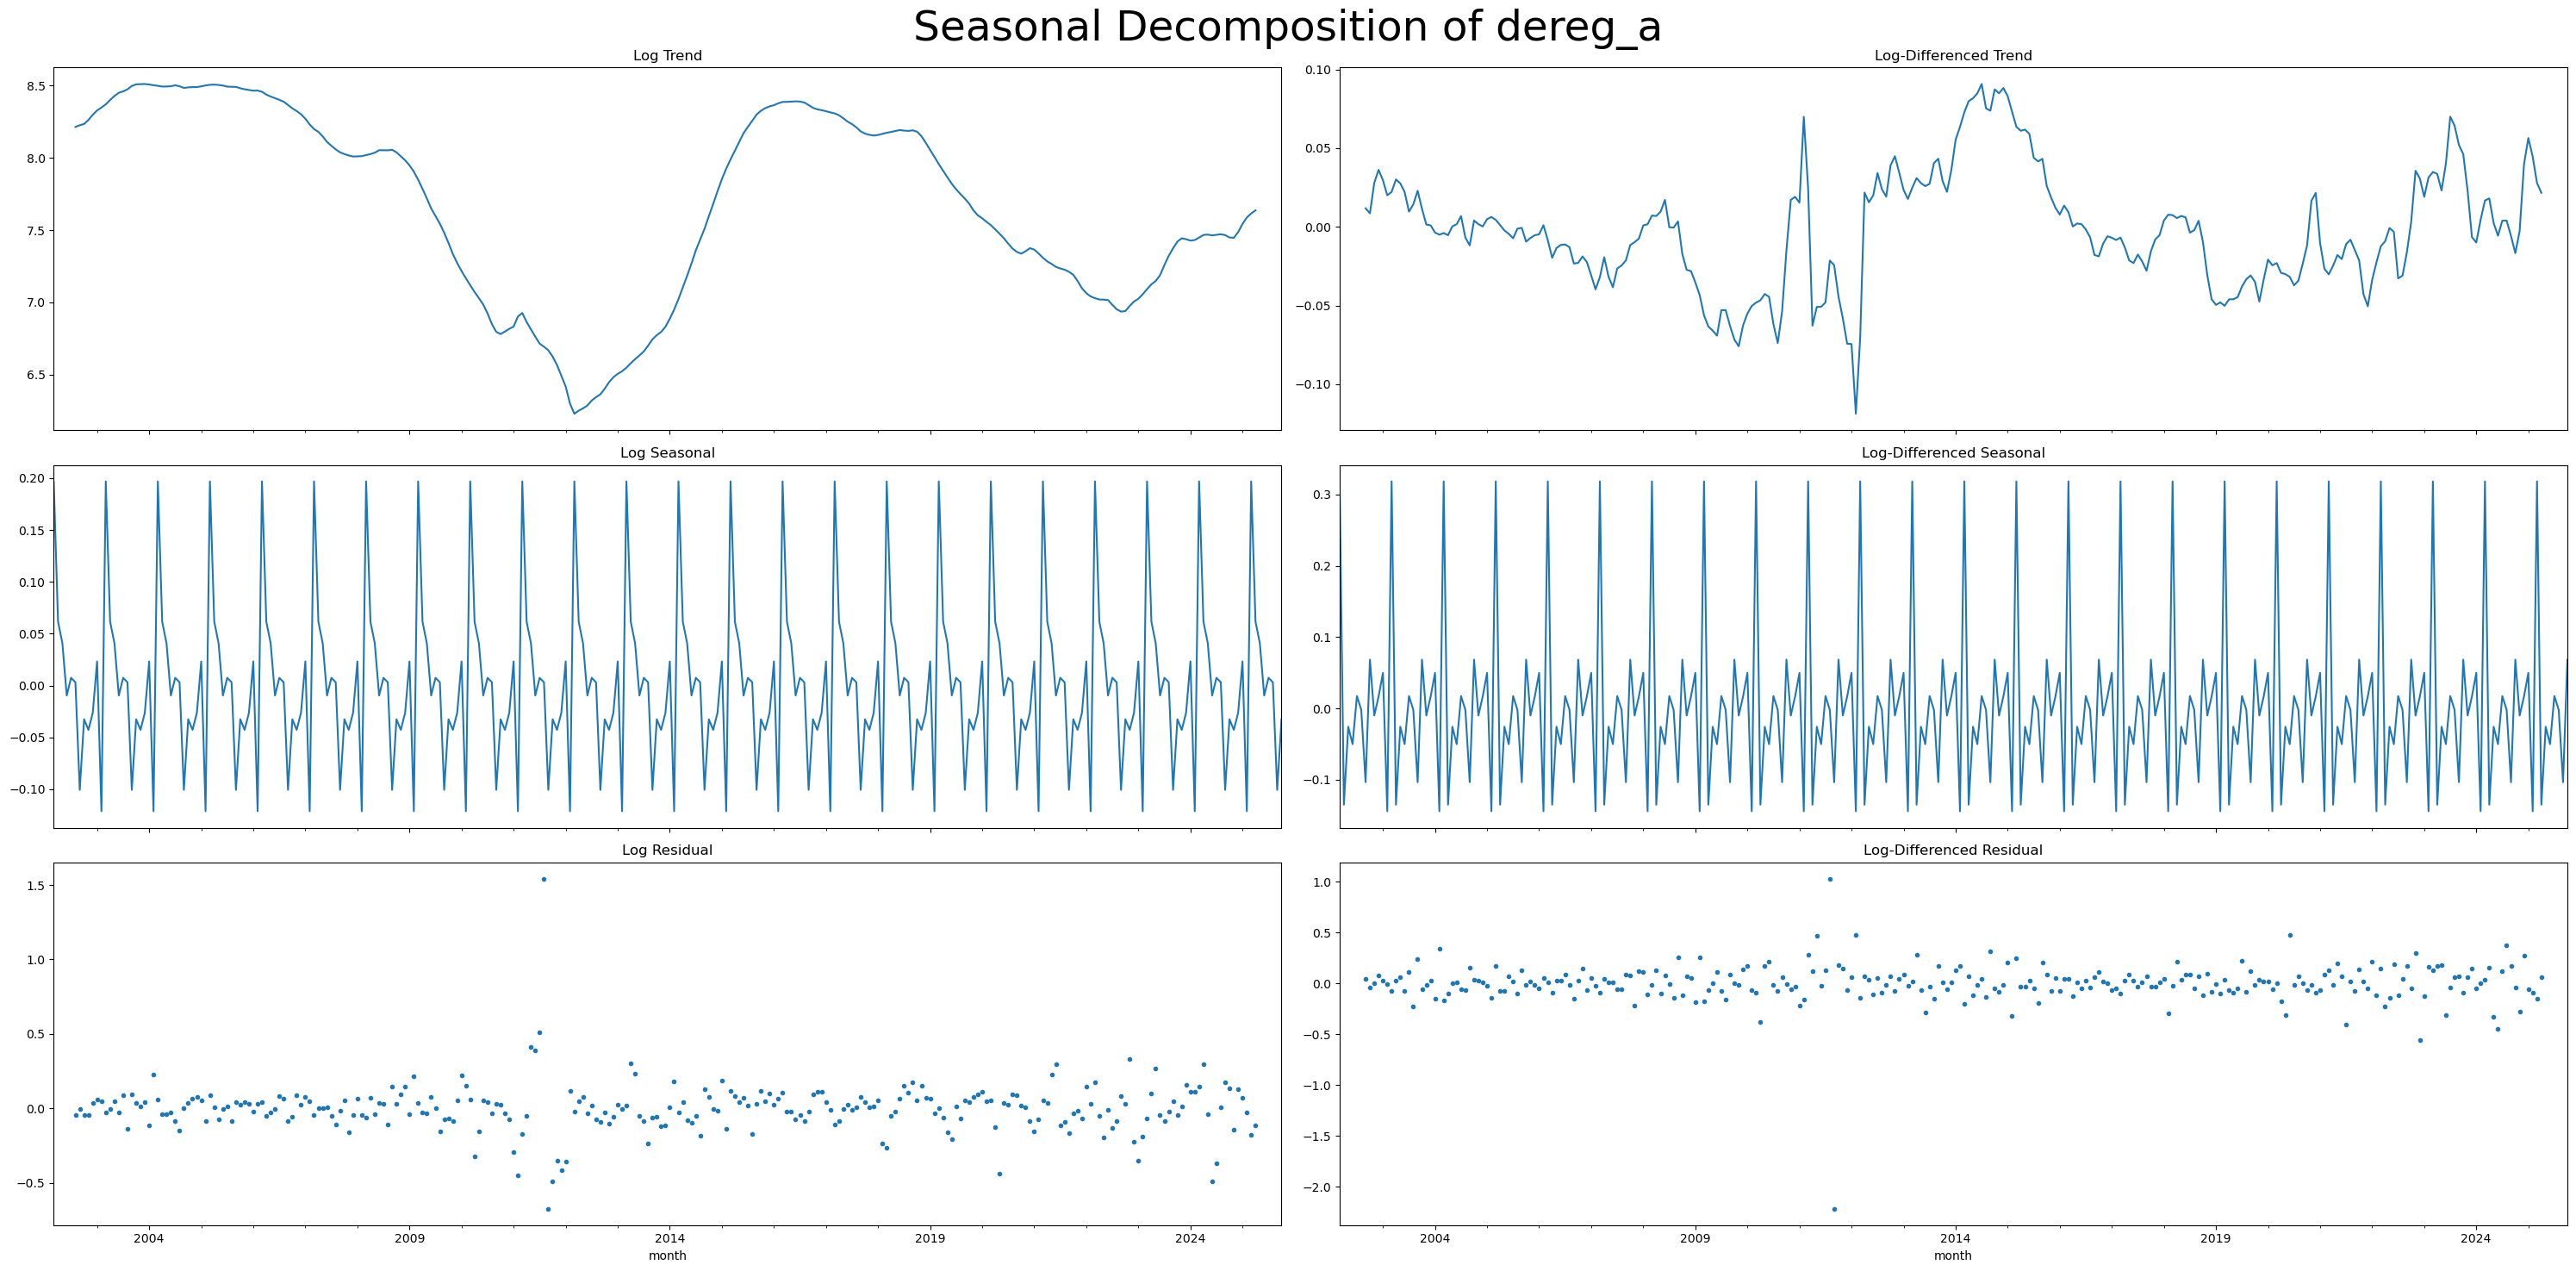

In [19]:
for col in new_cat_a.columns:
    decomposition_log = seasonal_decompose(log_cat_a[col], model='additive', period=period)
    decomposition_log_diff = seasonal_decompose(diff_log_cat_a[col], model='additive', period=period)

    components['log'][col] = {
        'trend': decomposition_log.trend,
        'seasonal': decomposition_log.seasonal,
        'residual': decomposition_log.resid
    }

    components['log_diff'][col] = {
        'trend': decomposition_log_diff.trend,
        'seasonal': decomposition_log_diff.seasonal,
        'residual': decomposition_log_diff.resid
    }

    fig, axes = plt.subplots(3, 2, figsize=(30, 15), sharex=True)
    fig.suptitle(f"Seasonal Decomposition of {col}", fontsize=35)

    decomposition_log.trend.plot(ax=axes[0, 0], title="Log Trend")
    decomposition_log.seasonal.plot(ax=axes[1, 0], title="Log Seasonal")
    decomposition_log.resid.plot(ax=axes[2, 0], title="Log Residual", style='.')

    decomposition_log_diff.trend.plot(ax=axes[0, 1], title="Log-Differenced Trend")
    decomposition_log_diff.seasonal.plot(ax=axes[1, 1], title="Log-Differenced Seasonal")
    decomposition_log_diff.resid.plot(ax=axes[2, 1], title="Log-Differenced Residual", style='.')

    plt.tight_layout()
    plt.show()

In [20]:
residuals_original = {
    col: components['original'][col]['residual'].dropna()
    for col in components['original'].keys()
}

residuals_differenced = {
    col: components['differenced'][col]['residual'].dropna()
    for col in components['differenced'].keys()
}

residuals_log = {
    col: components['log'][col]['residual'].dropna()
    for col in components['log'].keys()
}

residuals_log_diff = {
    col: components['log_diff'][col]['residual'].dropna()
    for col in components['log_diff'].keys()
}

In [21]:
def adf_test(series, name):
    result = adfuller(series)
    print(f"{name}: ADF Statistic = {result[0]:.3f}, p-value = {result[1]:.5f}")

def shapiro_test(series, name):
    stat, p = shapiro(series)
    print(f"{name}: Shapiro-Wilk Statistic = {stat:.3f}, p-value = {p:.5f}")

def ljung_box_test(series, name, lags=12):
    result = acorr_ljungbox(series, lags=[lags], return_df=True)
    print(f"{name}: Ljung-Box p-value = {result['lb_pvalue'].iloc[0]:.5f}")

def bp_test(series, name):
    residuals = series.values
    x = sm.add_constant(range(len(residuals)))
    _, pval, _, _ = sm.stats.diagnostic.het_breuschpagan(residuals, x)
    print(f"{name}: Breusch-Pagan p-value = {pval:.5f}")

for col, resid in residuals_original.items():
    print(f"\nTests for {col} (Original Residuals)")
    adf_test(resid, col)
    shapiro_test(resid, col)
    ljung_box_test(resid, col)
    bp_test(resid, col)

for col, resid in residuals_differenced.items():
    print(f"\nTests for {col} (Differenced Residuals)")
    adf_test(resid, col)
    shapiro_test(resid, col)
    ljung_box_test(resid, col)
    bp_test(resid, col)

for col, resid in residuals_log.items():
    print(f"\nTests for {col} (Log Residuals)")
    adf_test(resid, col)
    shapiro_test(resid, col)
    ljung_box_test(resid, col)
    bp_test(resid, col)

for col, resid in residuals_log_diff.items():
    print(f"\nTests for {col} (Log-Differenced Residuals)")
    adf_test(resid, col)
    shapiro_test(resid, col)
    ljung_box_test(resid, col)
    bp_test(resid, col)



Tests for quota_a (Original Residuals)
quota_a: ADF Statistic = -8.471, p-value = 0.00000
quota_a: Shapiro-Wilk Statistic = 0.994, p-value = 0.28583
quota_a: Ljung-Box p-value = 0.00000
quota_a: Breusch-Pagan p-value = 0.71278

Tests for bids_received_a (Original Residuals)
bids_received_a: ADF Statistic = -11.251, p-value = 0.00000
bids_received_a: Shapiro-Wilk Statistic = 0.965, p-value = 0.00000
bids_received_a: Ljung-Box p-value = 0.00000
bids_received_a: Breusch-Pagan p-value = 0.76854

Tests for quota_premium_a (Original Residuals)
quota_premium_a: ADF Statistic = -7.489, p-value = 0.00000
quota_premium_a: Shapiro-Wilk Statistic = 0.869, p-value = 0.00000
quota_premium_a: Ljung-Box p-value = 0.00000
quota_premium_a: Breusch-Pagan p-value = 0.73259

Tests for dereg_a (Original Residuals)
dereg_a: ADF Statistic = -9.829, p-value = 0.00000
dereg_a: Shapiro-Wilk Statistic = 0.619, p-value = 0.00000
dereg_a: Ljung-Box p-value = 0.00000
dereg_a: Breusch-Pagan p-value = 0.83128

Tests 

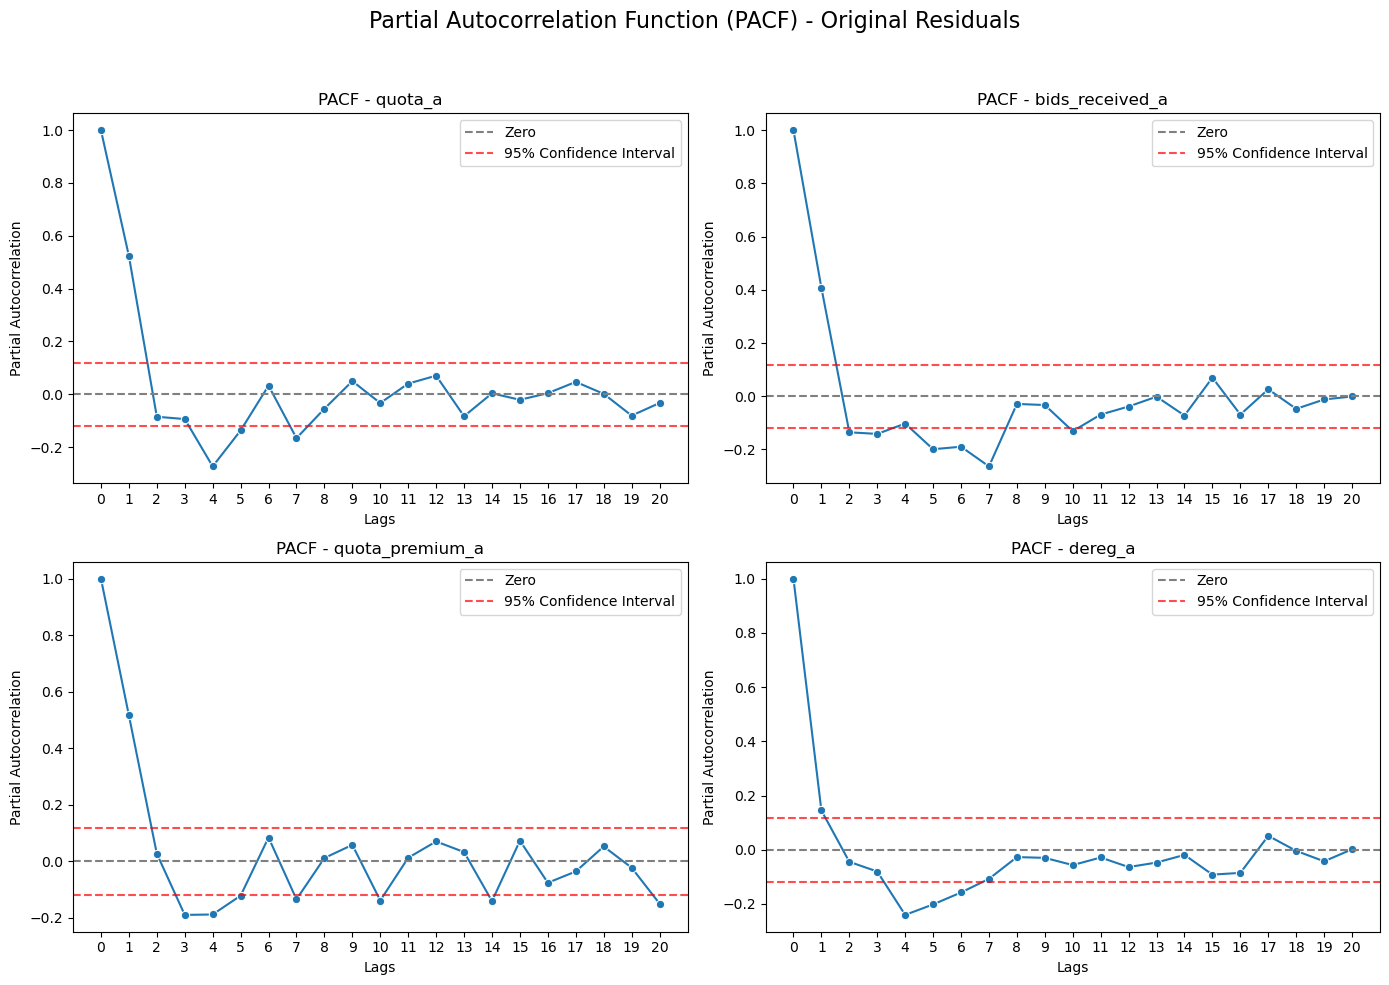

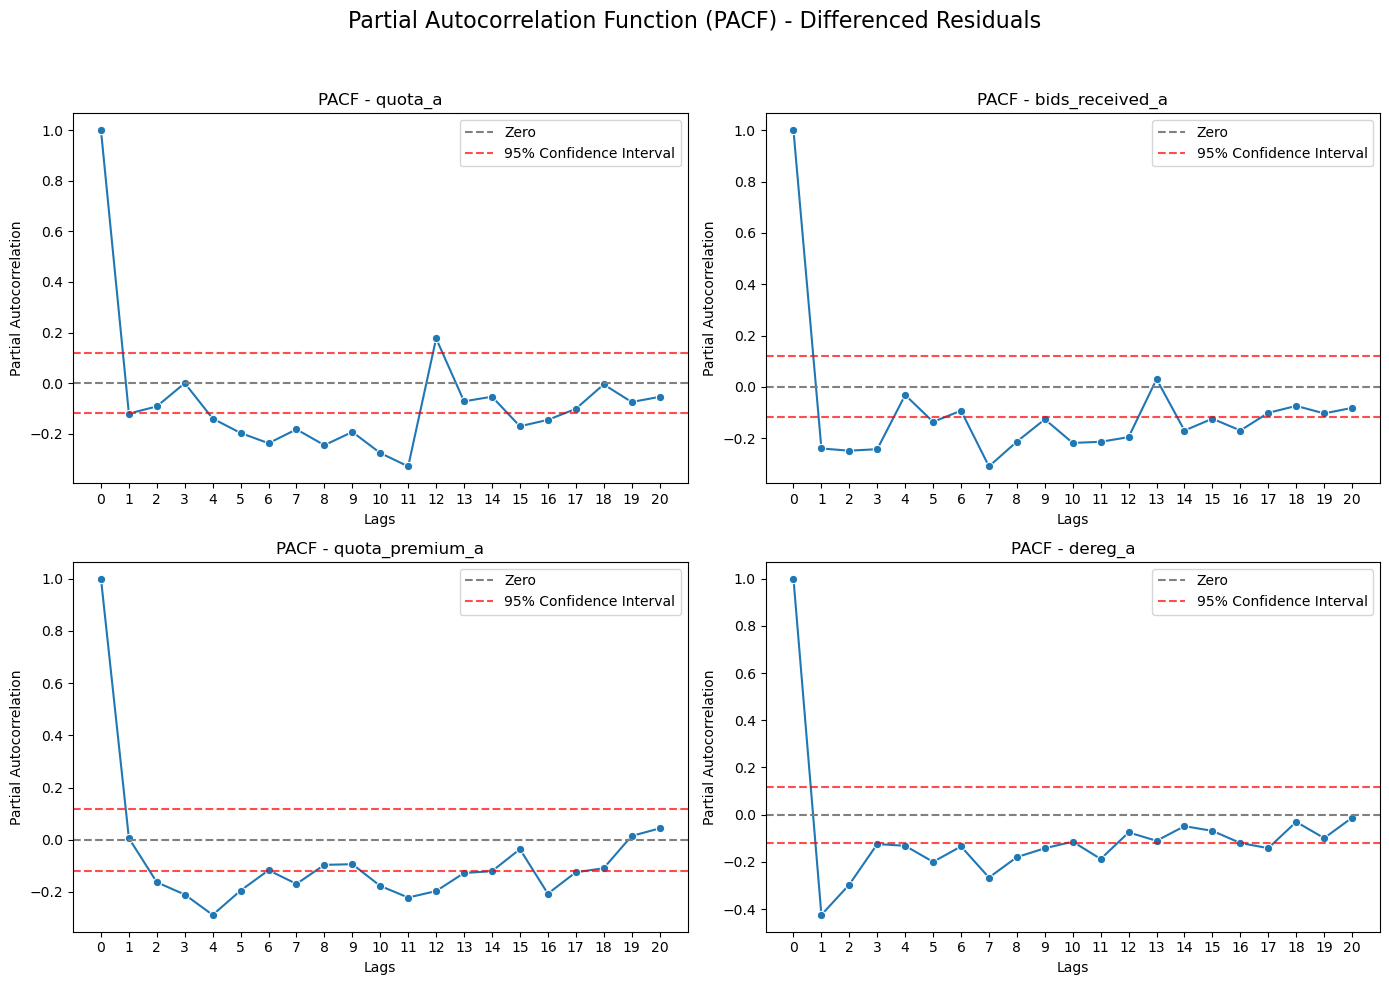

In [22]:
residuals_data = {
    'Original Residuals': residuals_original,
    'Differenced Residuals': residuals_differenced
}

for series_type, residuals in residuals_data.items():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Partial Autocorrelation Function (PACF) - {series_type}', fontsize=16)

    for i, (feature, resid) in enumerate(residuals.items()):
        pacf_vals = pacf(resid, nlags=20, method='ols')
        conf_int = 1.96 / np.sqrt(len(resid))
        
        ax = axes[i // 2, i % 2]
        sns.lineplot(x=range(len(pacf_vals)), y=pacf_vals, ax=ax, marker='o', )
        ax.axhline(y=0, linestyle='--', color='gray', label='Zero')
        ax.axhline(y=conf_int, linestyle='--', color='red', alpha=0.7, label='95% Confidence Interval')
        ax.axhline(y=-conf_int, linestyle='--', color='red', alpha=0.7)
        ax.set_title(f'PACF - {feature}')
        ax.set_xlabel('Lags')
        ax.set_xticks(range(len(pacf_vals)))
        ax.set_ylabel('Partial Autocorrelation')
        ax.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

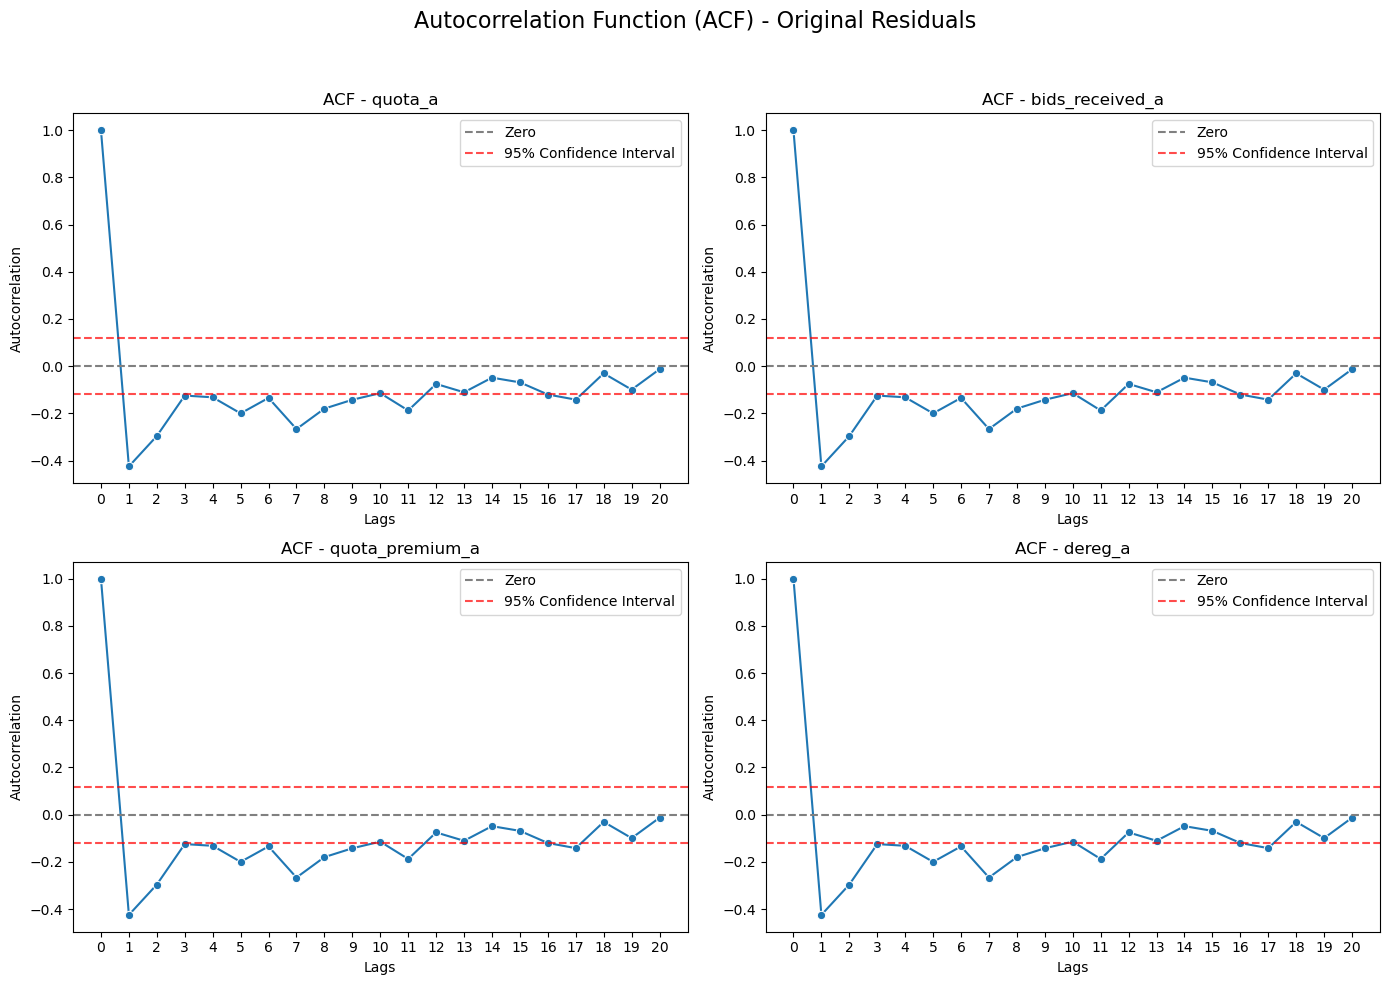

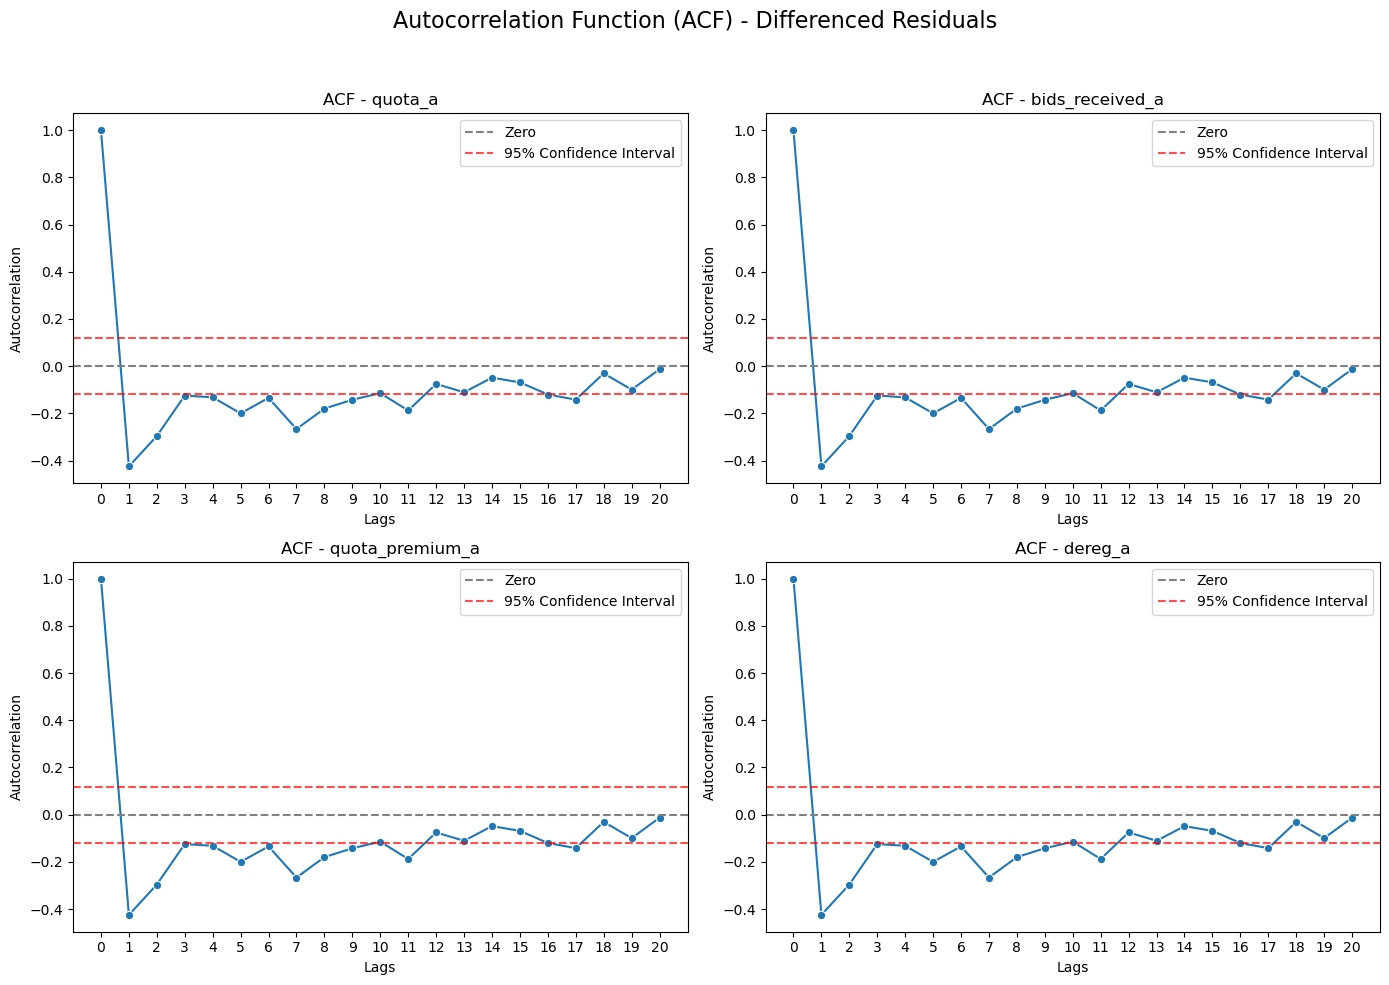

In [23]:
for series_type, residuals in residuals_data.items():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Autocorrelation Function (ACF) - {series_type}', fontsize=16)

    for i, (feature, resid) in enumerate(residuals.items()):
        acf_vals = acf(resid, nlags=20)
        conf_int = 1.96 / np.sqrt(len(resid))
        
        ax = axes[i // 2, i % 2]
        sns.lineplot(x=range(len(pacf_vals)), y=pacf_vals, ax=ax, marker='o', )
        ax.axhline(y=0, linestyle='--', color='gray', label='Zero')
        ax.axhline(y=conf_int, linestyle='--', color='red', alpha=0.7, label='95% Confidence Interval')
        ax.axhline(y=-conf_int, linestyle='--', color='red', alpha=0.7)
        ax.set_title(f'ACF - {feature}')
        ax.set_xlabel('Lags')
        ax.set_xticks(range(len(pacf_vals)))
        ax.set_ylabel('Autocorrelation')
        ax.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [24]:
from statsmodels.tsa.arima.model import ARIMA

ar_model_quota_premium_residuals = ARIMA(residuals_original['quota_premium_a'], order=(1, 0, 0)).fit()
print("Model Summary:\n", ar_model_quota_premium_residuals.summary())


Model Summary:
                                SARIMAX Results                                
Dep. Variable:                  resid   No. Observations:                  273
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 276.943
Date:                Tue, 27 Jan 2026   AIC                           -547.886
Time:                        18:06:38   BIC                           -537.058
Sample:                    08-01-2002   HQIC                          -543.539
                         - 04-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9925      0.012     82.120      0.000       0.969       1.016
ar.L1          0.5144      0.026     19.599      0.000       0.463       0.566
sigma2         0.0077      0.000    

c:\Users\EK\anaconda3\envs\datascience\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

c:\Users\EK\anaconda3\envs\datascience\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

c:\Users\EK\anaconda3\envs\datascience\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.



In [25]:
from arch import arch_model

ar_garch_model = arch_model(
    residuals_original['quota_premium_a'],
    mean='AR',
    lags=1,
    vol='Garch',   
    p=1, q=1
)


ar_garch_fit = ar_garch_model.fit(update_freq=5)
print("AR-GARCH Model Summary:\n", ar_garch_fit.summary())

Iteration:      5,   Func. Count:     47,   Neg. LLF: -320.67203145696453
Iteration:     10,   Func. Count:     80,   Neg. LLF: -326.0929256394137
Optimization terminated successfully    (Exit mode 0)
            Current function value: -326.09292563945155
            Iterations: 10
            Function evaluations: 80
            Gradient evaluations: 10
AR-GARCH Model Summary:
                            AR - GARCH Model Results                           
Dep. Variable:                  resid   R-squared:                       0.263
Mean Model:                        AR   Adj. R-squared:                  0.260
Vol Model:                      GARCH   Log-Likelihood:                326.093
Distribution:                  Normal   AIC:                          -642.186
Method:            Maximum Likelihood   BIC:                          -624.157
                                        No. Observations:                  272
Date:                Tue, Jan 27 2026   Df Residuals:           

c:\Users\EK\anaconda3\envs\datascience\lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.007716. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.




In [26]:
scaled_residuals = residuals_original['quota_premium_a'] * 100  # Rescale
ar_garch_model_rescaled = arch_model(
    scaled_residuals, mean='AR', lags=1, vol='Garch', p=1, q=1
)
ar_garch_fit_rescaled = ar_garch_model_rescaled.fit(update_freq=5)
print(ar_garch_fit_rescaled.summary())

Iteration:      5,   Func. Count:     38,   Neg. LLF: 1092.905068753088
Iteration:     10,   Func. Count:     70,   Neg. LLF: 926.513607227497
Optimization terminated successfully    (Exit mode 0)
            Current function value: 926.5133645670924
            Iterations: 13
            Function evaluations: 87
            Gradient evaluations: 13
                           AR - GARCH Model Results                           
Dep. Variable:                  resid   R-squared:                       0.263
Mean Model:                        AR   Adj. R-squared:                  0.260
Vol Model:                      GARCH   Log-Likelihood:               -926.513
Distribution:                  Normal   AIC:                           1863.03
Method:            Maximum Likelihood   BIC:                           1881.06
                                        No. Observations:                  272
Date:                Tue, Jan 27 2026   Df Residuals:                      270
Time:           

In [27]:
seasonal_components = {
    'bids_received_a': decomposition_original['bids_received_a'].seasonal,
    'quota_premium_a': decomposition_original['quota_premium_a'].seasonal,
    'dereg_a': decomposition_original['dereg_a'].seasonal,
}

monthly_seasonal = {}
for feature, seasonal_series in seasonal_components.items():
    seasonal_series = seasonal_series.groupby(seasonal_series.index.month).mean()
    monthly_seasonal[feature] = seasonal_series

fig = go.Figure()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for feature, seasonal_values in monthly_seasonal.items():
    fig.add_trace(go.Scatter(
        x=months,
        y=seasonal_values,
        mode='lines+markers',
        name=feature
    ))

fig.update_layout(
    title="Seasonal Components for Features",
    xaxis_title="Month",
    yaxis_title="Seasonal Effect",
    template="plotly_dark",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.3,
        xanchor="center",
        x=0.5
    )
)

fig.show()


TypeError: 'DecomposeResult' object is not subscriptable

In [ ]:
february_data = new_cat_a[new_cat_a.index.month == 2]
apr_data = new_cat_a[new_cat_a.index.month == 4]

monthly_averages = new_cat_a.groupby(new_cat_a.index.month).mean()
february_average = monthly_averages.loc[2]
apr_average = monthly_averages.loc[4]

print("February Averages:")
print(february_average)
print("April Averages:")
print(apr_average)
print("Overall Monthly Averages:")
print(monthly_averages.mean())

February Averages:
quota_a             2782.565217
bids_received_a     4136.173913
quota_premium_a    40254.543478
dereg_a             2408.130435
Name: 2, dtype: float64
April Averages:
quota_a             2563.426087
bids_received_a     3905.447826
quota_premium_a    43912.239130
dereg_a             2827.173913
Name: 4, dtype: float64
Overall Monthly Averages:
quota_a             2659.589625
bids_received_a     3756.921805
quota_premium_a    43422.915431
dereg_a             2687.819993
dtype: float64


In [ ]:
from scipy.stats import ttest_1samp

def one_sample_t_test(month_values, overall_mean):
    t_test_results = {}
    for col in month_values.columns:
        t_stat, p_value = ttest_1samp(month_values[col].dropna(), overall_mean[col])
        t_test_results[col] = {'t_stat': t_stat, 'p_value': p_value}
    return t_test_results

february_t_test_results = one_sample_t_test(february_data, monthly_averages.mean())
print("February T-Test Results:")
for feature, result in february_t_test_results.items():
    print(f"{feature}: t_stat={result['t_stat']:.3f}, p_value={result['p_value']:.3f}")

april_t_test_results = one_sample_t_test(apr_data, monthly_averages.mean())
print("\nApril T-Test Results:")
for feature, result in april_t_test_results.items():
    print(f"{feature}: t_stat={result['t_stat']:.3f}, p_value={result['p_value']:.3f}")



February T-Test Results:
quota_a: t_stat=0.384, p_value=0.705
bids_received_a: t_stat=0.776, p_value=0.446
quota_premium_a: t_stat=-0.616, p_value=0.544
dereg_a: t_stat=-0.950, p_value=0.352

April T-Test Results:
quota_a: t_stat=-0.347, p_value=0.732
bids_received_a: t_stat=0.390, p_value=0.700
quota_premium_a: t_stat=0.093, p_value=0.927
dereg_a: t_stat=0.438, p_value=0.665



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=11.4653 , p=0.0008  , df_denom=270, df_num=1
ssr based chi2 test:   chi2=11.5927 , p=0.0007  , df=1
likelihood ratio test: chi2=11.3533 , p=0.0008  , df=1
parameter F test:         F=11.4653 , p=0.0008  , df_denom=270, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=5.7869  , p=0.0035  , df_denom=267, df_num=2
ssr based chi2 test:   chi2=11.7906 , p=0.0028  , df=2
likelihood ratio test: chi2=11.5422 , p=0.0031  , df=2
parameter F test:         F=5.7869  , p=0.0035  , df_denom=267, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=4.6522  , p=0.0035  , df_denom=264, df_num=3
ssr based chi2 test:   chi2=14.3268 , p=0.0025  , df=3
likelihood ratio test: chi2=13.9609 , p=0.0030  , df=3
parameter F test:         F=4.6522  , p=0.0035  , df_denom=264, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=3.3484  , p=0.0107  

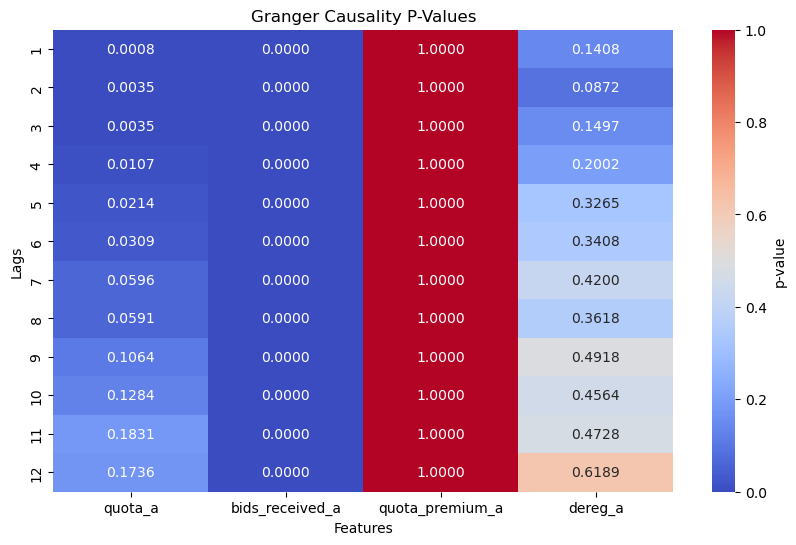

In [ ]:
granger_data = diff_log_cat_a[['quota_a', 'bids_received_a', 'quota_premium_a', 'dereg_a']]
max_lag = 12

target_feature = 'quota_premium_a'
independent_features = ['quota_a', 'bids_received_a', 'quota_premium_a', 'dereg_a']

granger_results = pd.DataFrame(index=range(1, max_lag + 1), columns=independent_features)

for col in independent_features:
    test_result = grangercausalitytests(granger_data[[col, target_feature]].dropna(), maxlag=max_lag)
    # Extract p-values for each lag
    p_values = [test_result[i + 1][0]['ssr_ftest'][1] for i in range(max_lag)]
    granger_results[col] = p_values

print(granger_results)

plt.figure(figsize=(10, 6))
sns.heatmap(granger_results, annot=True, fmt=".4f", cmap="coolwarm", cbar_kws={'label': 'p-value'})
plt.title("Granger Causality P-Values")
plt.xlabel("Features")
plt.ylabel("Lags")
plt.show()

Spearman Correlation Matrix:
                  quota_a  bids_received_a  quota_premium_a   dereg_a
quota_a          1.000000         0.431592        -0.101291  0.085159
bids_received_a  0.431592         1.000000         0.106236  0.169305
quota_premium_a -0.101291         0.106236         1.000000  0.060941
dereg_a          0.085159         0.169305         0.060941  1.000000

P-Value Matrix:
                      quota_a  bids_received_a  quota_premium_a   dereg_a
quota_a          0.000000e+00     7.374013e-14         0.094266  0.159800
bids_received_a  7.374013e-14     0.000000e+00         0.079183  0.004954
quota_premium_a  9.426606e-02     7.918327e-02         0.000000  0.314862
dereg_a          1.598002e-01     4.954065e-03         0.314862  0.000000


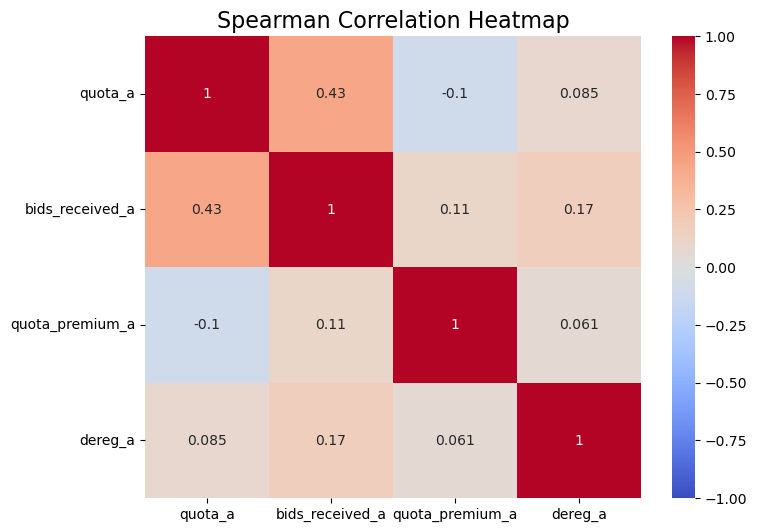

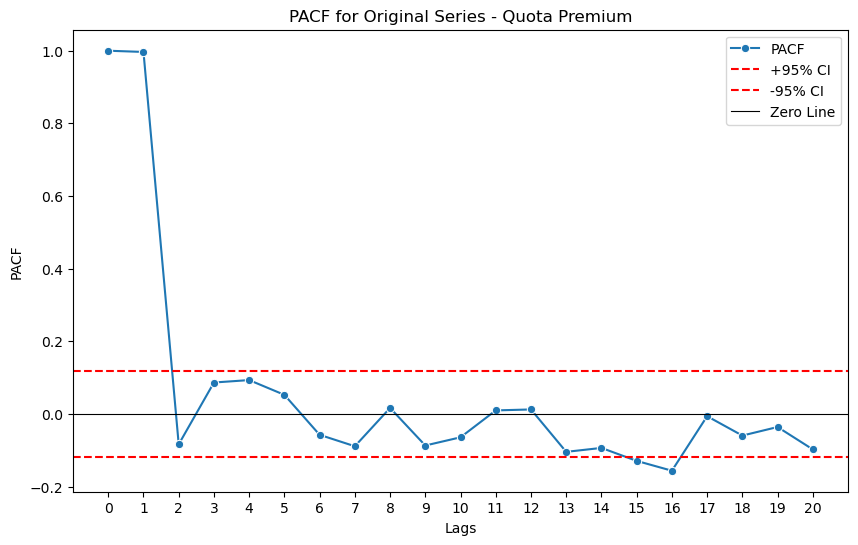

In [ ]:
from statsmodels.tsa.stattools import pacf

x_pacf = pacf(new_cat_a['quota_premium_a'], nlags=20, method='ols')

N = len(new_cat_a['quota_premium_a'].dropna())
conf_interval = 1.96 / np.sqrt(N)

plt.figure(figsize=(10, 6))
sns.lineplot(x=range(len(x_pacf)), y=x_pacf, marker='o', label='PACF')
plt.axhline(y=conf_interval, color='red', linestyle='--', label='+95% CI')
plt.axhline(y=-conf_interval, color='red', linestyle='--', label='-95% CI')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8, label='Zero Line')

plt.title("PACF for Original Series - Quota Premium", fontsize=12)
plt.xlabel("Lags")
plt.xticks(range(len(x_pacf)))
plt.ylabel("PACF")
plt.legend()
plt.show()

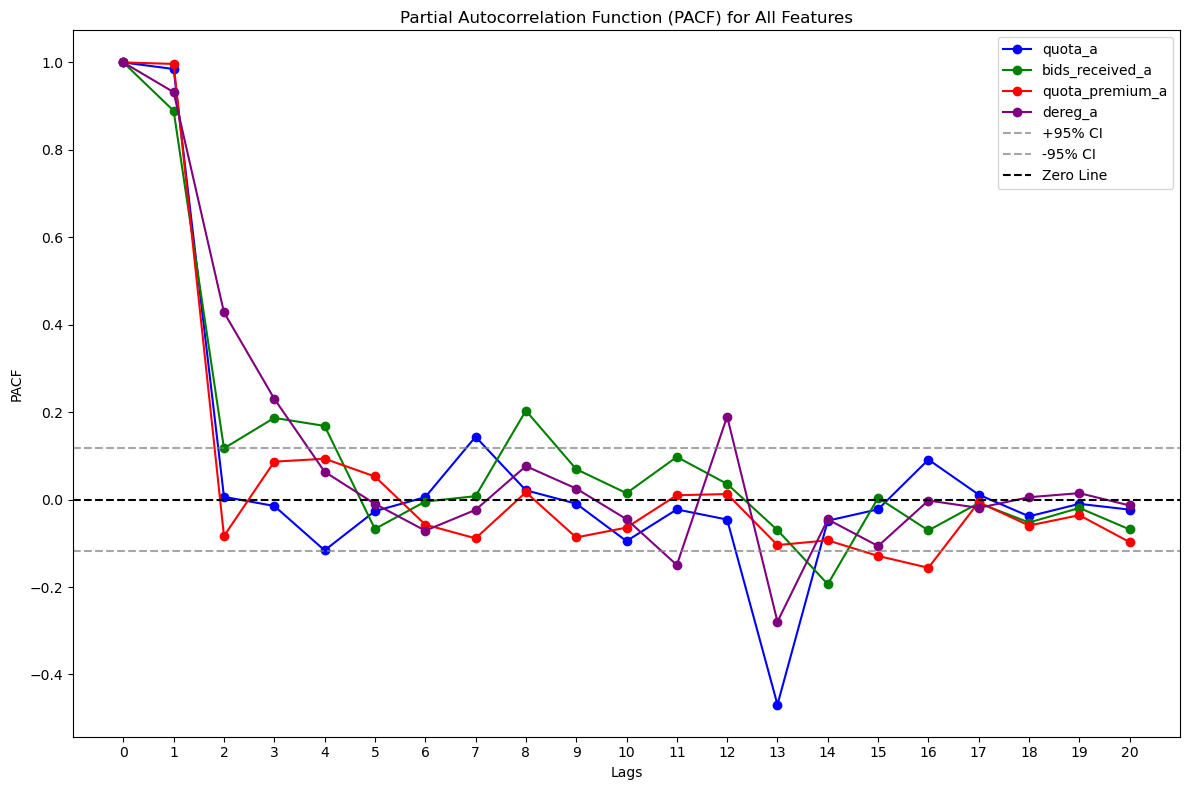

In [ ]:
features = ['quota_a', 'bids_received_a', 'quota_premium_a', 'dereg_a']
colors = ['blue', 'green', 'red', 'purple']  # Colors for different features
nlags = 20

plt.figure(figsize=(12, 8))

for feature, color in zip(features, colors):
    # Calculate PACF values
    pacf_vals = pacf(new_cat_a[feature].dropna(), nlags=nlags, method='ols')
    
    # Plot PACF values as a line
    plt.plot(range(len(pacf_vals)), pacf_vals, marker='o', label=feature, color=color)

# Add confidence interval lines
conf_interval = 1.96 / np.sqrt(len(new_cat_a))
plt.axhline(y=conf_interval, linestyle='--', color='gray', alpha=0.7, label='+95% CI')
plt.axhline(y=-conf_interval, linestyle='--', color='gray', alpha=0.7, label='-95% CI')
plt.axhline(y=0, linestyle='--', color='black', label='Zero Line')

# Customize the plot
plt.title('Partial Autocorrelation Function (PACF) for All Features')
plt.xlabel('Lags')
plt.ylabel('PACF')
plt.xticks(range(nlags + 1))
plt.legend()
plt.tight_layout()
plt.show()